In [2]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
from datasets.dataset import SimulationXZDataset
import time 
import time 
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
from skimage.metrics import structural_similarity as ssim_id
import numpy as np
import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
from datasets.dataset import TemperatureXZDataset
from runners.train_diffusion import forwardpass
from analysis_functions import predict_lrenc, predict_mobilenet, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM, predict_modified_diffusion

In [3]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

In [4]:
def plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct', save = False, mpfname = '', kpfname = ''):
    profile_result, kp_result = get_profile(result)

    profile_gt, kp_gt = get_profile(target)
    profile_input, kp_input = get_profile(input, mesh = 20)

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20), kp_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), kp_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80), kp_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Keyhole Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    if save:
        print('Saving')
        plt.savefig(kpfname)
    else:
        plt.show()

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), profile_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Melt Pool Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    if save:
        plt.savefig(mpfname)
    else:
        plt.show()
    plt.show()
def plot_temp_lines(input, result, target, modeltype, split = 'train', save = False, fname = ''):
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'direct'
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.title(r'{} model, Cross section: x = 200 $\mu m$'.format(modeltype))
    plt.plot(80*5*(np.arange(input.shape[-1])/input.shape[-1]),input[10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),target[40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),result[40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    if save:
        plt.savefig(fname)
    else:
        plt.show()
    # plt.show()

In [5]:

device = 'cuda'


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a



def predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, encoding, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if encoding:
            # x_e = forwardpass(lr_enc, lr.to(device).float(), factor = train_dataset.factor)
        if len(lr.shape)< 4:
            x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float())
        else:
            x_e = forwardpass(lr_enc, lr.to(device).float())
    else:
        x_e = upscaled_lr.to(device).float().repeat(1,1,1, 1)
    
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    # with torch.no_grad():
    #     n = img.size(0)
    #     seq_next = [-1] + list(seq[:-1])
    #     x0_preds = []
        
    #     x = torch.randn(shape, device=device)
    #     xs = [x]
    #     for i, j in zip(reversed(seq), reversed(seq_next)):
    #         t = (torch.ones(n) * i).to(x.device)
    #         next_t = (torch.ones(n) * j).to(x.device)
    #         at = compute_alpha(b, t.long())
    #         at_next = compute_alpha(b, next_t.long())
    #         xt = xs[-1].to('cuda')
    #         et = model(x, t, x_e)#model(xt, t)
    #         x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
    #         x0_preds.append(x0_t.to('cpu'))
    #         c1 = (
    #             kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
    #         )
    #         c2 = ((1 - at_next) - c1 ** 2).sqrt()
    #         xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
    #         xs.append(xt_next.to('cpu'))
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b





### Define results directory and general parameters

In [21]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_04_14_33_46/rescaling/n_steps_3'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_02_26_02_05_27/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionexplicitencoded/2023_02_15_11_20_16/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionexplicitencoded/2023_02_15_11_20_16/standardize/n_steps_1'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_04_14_33_46/rescaling/n_steps_3'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_02_26_02_05_27/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_02_14_20_37_48/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_02_14_20_37_48/standardize/n_steps_1'
timesteps = 1000
conditioning = 'implicit'
encoding = 'True'
schedule = 'linear'
device= 'cuda'
encode_bool = encoding == 'True'

os.environ['CUDA_VISIBLE_DEVICES']  = "6"
batch_size = 1
downscale_method = 'direct'
analysis_folder = f'analyzed_figures_paper_3_4/{timesteps}_{conditioning}_{schedule}_{downscale_method}'
os.makedirs( analysis_folder, exist_ok = True)

data_folder = '/home/oogoke/DiffusionSR/datasets/simulation_basis_v3_laser_velocity_xz_cross_section_data'#'/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data'#'/home/oogoke/DiffusionSR/datasets/simulation_basis_laser_velocity_xz_cross_section_data'
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = data_folder , return_info = True, normalize = 'rescaling', n_steps = 3)
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = data_folder, return_info = True, normalize = 'rescaling', n_steps = 3)
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = data_folder, return_info = True, normalize = 'rescaling', n_steps = 3)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)


Using normalize method: ... rescaling
Using all 1 fields
Processing dataset with 1 fields
Using normalize method: ... rescaling
Using all 1 fields
Processing dataset with 1 fields
Using normalize method: ... rescaling
Using all 1 fields
Processing dataset with 1 fields


### Plot Train, Test Loss for diffusion

In [7]:

test_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'validation_loss_epoch.txt'))
train_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'loss_epoch.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Validation Loss')
plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()
plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()
plt.savefig(os.path.join(analysis_folder, 'diff_loss_linear_scale.png'))
plt.show()
plt.clf()
plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)
plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Validation Loss')
plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()
plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')

plt.grid(which = 'major')
frame_tick()
plt.yscale('log')
plt.savefig(os.path.join(analysis_folder, 'diff_loss_log_scale.png'))
plt.show()
plt.clf()
plt.close('all')

OSError: /home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_04_14_28_07/rescaling/n_steps_1/validation_loss_epoch.txt not found.

### Defining simulation object for plotting loss curves

In [22]:
class Simulation():
    def __init__(self, folder, diff_steps, schedule):
        self.folder = folder
        self.diff_steps = diff_steps
        self.schedule = schedule
        self.kp = None
        self.profile = None
        self.max_depth = None
        self.kp_depth = None
    def get_loss_curve(self):
        test_loss = np.loadtxt(os.path.join(self.folder, 'validation_loss_epoch.txt'))
        train_loss = np.loadtxt(os.path.join(self.folder, 'loss_epoch.txt'))
        return train_loss, test_loss


### Demonstration: Plotting loss curves 

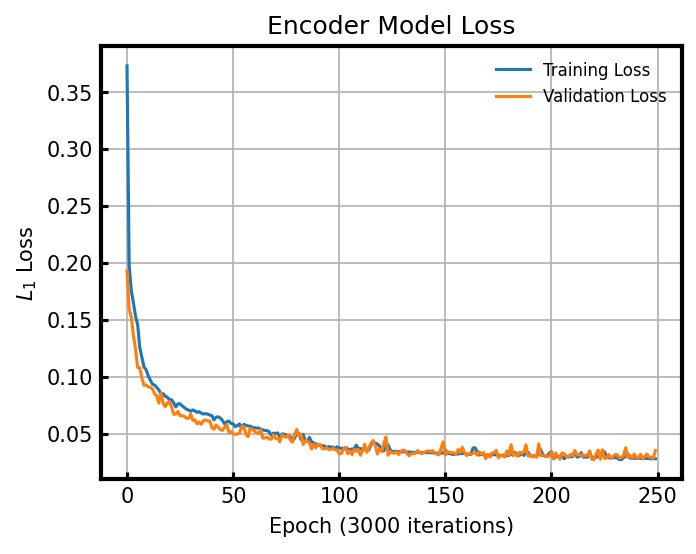

<Figure size 640x480 with 0 Axes>

In [23]:
test_loss = np.loadtxt(os.path.join(encoder_results_dir, 'test_loss.txt'))
train_loss = np.loadtxt(os.path.join(encoder_results_dir, 'train_loss.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss, label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Encoder Model Loss')
plt.grid(which = 'major')
frame_tick()
plt.show()
# plt.savefig(os.path.join(analysis_folder, 'encoder_loss_linear_scale.png'))
plt.clf()

### Initialize encoder and diffusion models

In [25]:
from runners.train_diffusion import DiffusionModel

def initialize_diffusion(diff_dir, enc_dir, datasets, timesteps, conditioning, encoding, schedule, device):
    ''' 
    Parameters:
        diff_dir: (str) Diffusion results directory
        enc_dir: (str) Encoder results directory
        datasets: (tuple or list) The three dataset objects corresponding to the train/validation/test splits, in the order (train, validation, test).
        timesteps: (int) The number of timesteps used for the diffusion model during training
        conditioning: (boolean) If true, the diffusion model assumes the LR passes through an encoder before being used for conditioning
        schedule: (str) Variance schedule used for training the diffusion model
        device: (str) 'cuda' for GPU, 'cpu' for CPU.
    Returns:
        diffusion_model: Custom DiffusionModel object that enables sampling with either DDIM or DDPM samplers.
    '''

    diffusion_model = DiffusionModel(results_folder=diff_dir,
                                    lr_encoder_folder=enc_dir,
                                    train_dataset=datasets[0],
                                    dev_dataset=datasets[1],
                                    test_dataset=datasets[2],
                                    timesteps=timesteps,
                                    conditioning=conditioning,
                                    encoding=encoding,
                                    schedule=schedule,
                                    device=device,enc_output=False
                                    )
    diffusion_model.load_saved_model()
    return diffusion_model

diff_model = initialize_diffusion(diff_dir=diffusion_results_dir,
                                  enc_dir=encoder_results_dir,
                                  datasets=[train_dataset,
                                            dev_dataset, test_dataset],
                                  timesteps=timesteps,
                                  conditioning=conditioning,
                                  encoding=encoding,
                                  schedule=schedule,
                                  device=device)


lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)


Loading encoder ... encoding = True
TIMESTEPS == 1000, Schedule = linear
Loading model from /home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_04_14_33_46/rescaling/n_steps_3
model found, loading


### Define diffusion prediction function
Note: This may eventually be moved to analysis_functions.py, but is provided here to allow for easier editing/debugging

In [12]:
def predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dataset, skip = 50):

    '''
    Return the predictions for the Diffusion model given an input batch
    Parameters:
    diff_model: DiffusionModel object
    lr_enc: Torch network module object, representing the trained RRDN encoder model
    res: Torch tensor, Residual between HR and LR data
    hr: Torch tensor, High Resolution data
    lr: Torch tensor, Low Resolution data
    upscaled_lr: Torch tensor, Bicubic upscaled low resolution data
    dataset: Dataset object, used for rescaling data
    Returns:
    Low resolution data, scaled to original space, 4-D numpy array (batch, channels, height, width)
    Output (Super-resolution), scaled to original space, 4-D numpy array
    High resolution data, scaled to original space, 4-D numpy array 
    '''

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape) < 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = dataset.factor)
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float(), factor = dataset.factor)
        x_e = forwardpass(lr_enc, lr.to(device).float())
        all_images = diff_model.batch_sample(dataset = train_dataset, batch = hr, x_e = x_e, sampler = 'DDIM', skip= skip)                
        result = dataset.unscale_data(all_images.cpu().numpy()[-1, 0], input_type = 'residual') + dataset.unscale_data(upscaled_lr.numpy(), input_type = 'upscaled_lr')
        
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr')
skip = 30
for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(train_dataloader):            
    #input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
    input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
    break


Saving


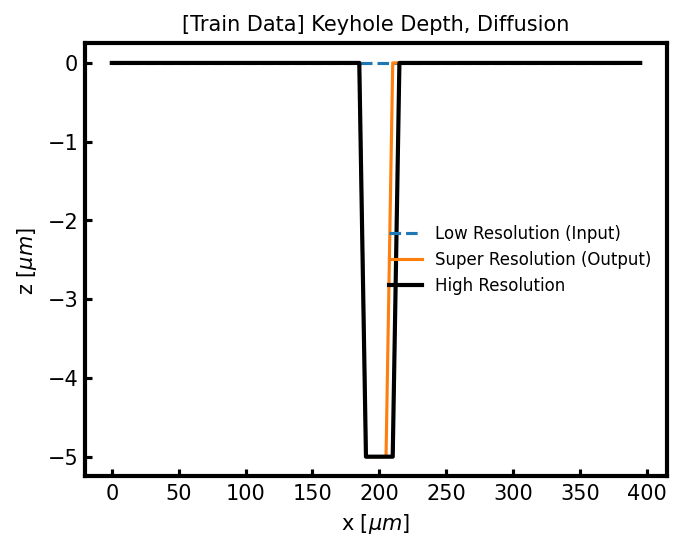

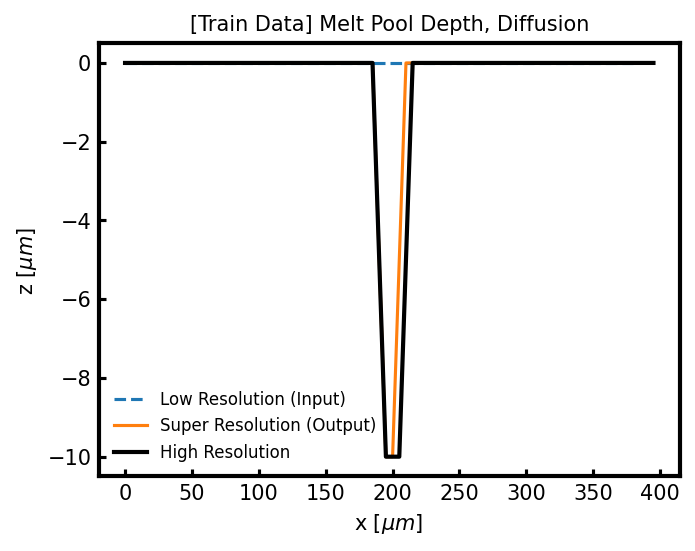

Saving


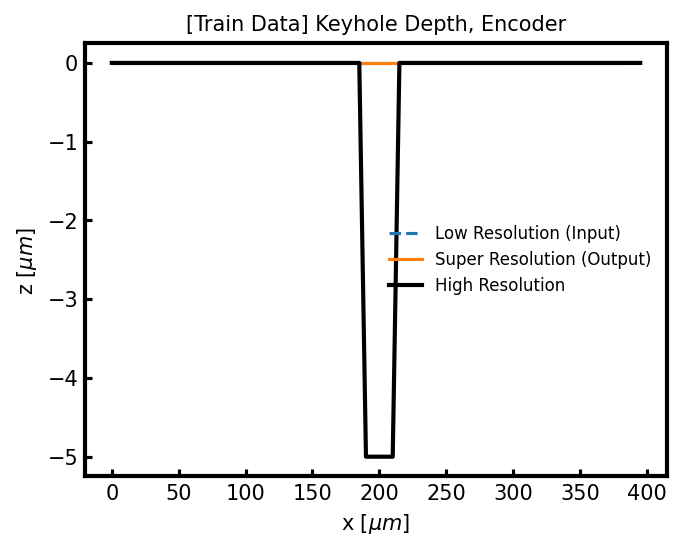

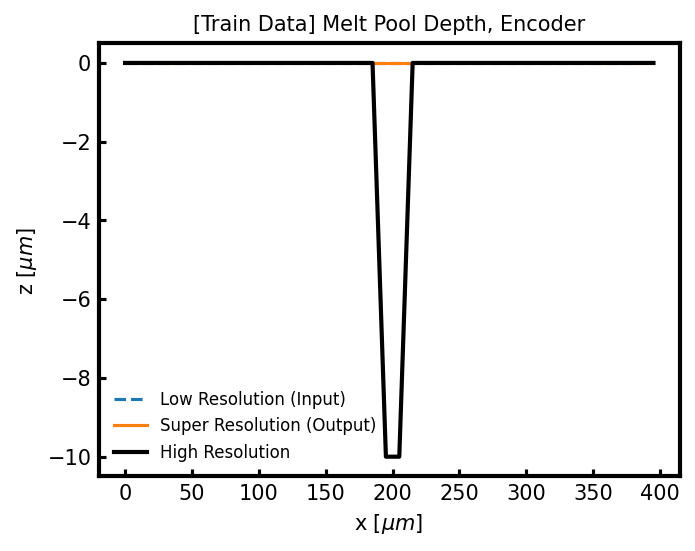

In [13]:

input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
split = 'Train'
kpfname = os.path.join(analysis_folder, f'diffusion_contour_line_{split}_plot_kp.png')
mpfname = os.path.join(analysis_folder, f'diffusion_contour_line_{split}_plot_mp.png')
plot_srdiff_contours(input, result_diffusion, target[0], split = 'Train', modeltype = "Diffusion", save = True, kpfname = kpfname, mpfname = mpfname )
# plt.savefig(os.path.join(analysis_folder, 'diffusion_train_contour_plot'))

kp_fname = os.path.join(analysis_folder, f'encoder_contour_line_{split}_plot_kp.png')
mpfname = os.path.join(analysis_folder, f'encoder_contour_line_{split}_plot_mp.png')
plot_srdiff_contours(input, lr_enc_result, target[0], split = 'Train', modeltype = "Encoder", save = True, kpfname = kpfname, mpfname = mpfname)
# plt.savefig(os.path.join(analysis_folder, 'encoder_train_contour_plot.png'))


plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Train', modeltype = "Encoder", save = True, title = os.path.join(analysis_folder, 'encoder_train_image_plot'))
# plt.savefig()

plot_images(input[0], result_diffusion[0], target[0][0], split = 'Train', modeltype = "Diffusion", save = True, title = os.path.join(analysis_folder, 'diffusion_train_image_plot') )


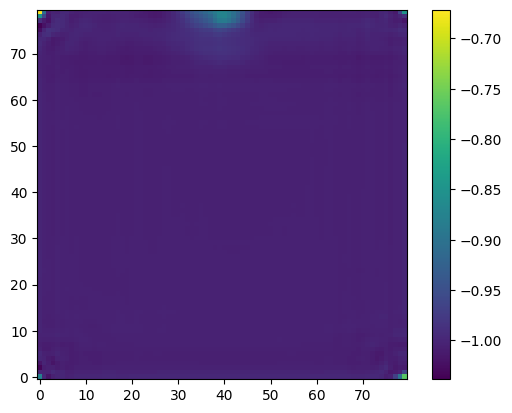

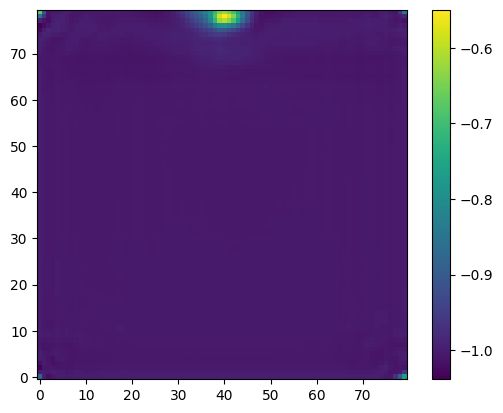

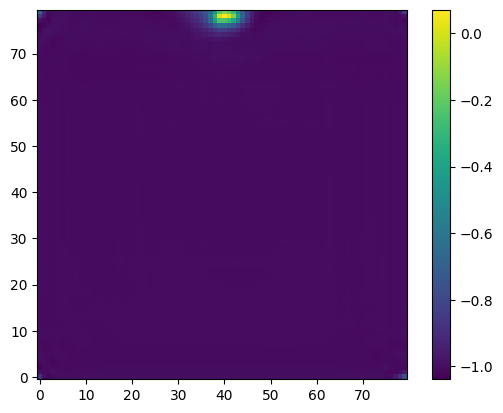

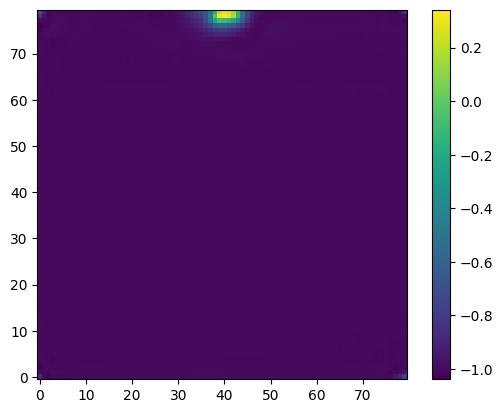

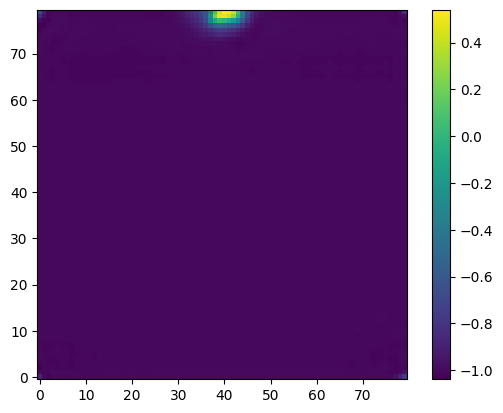

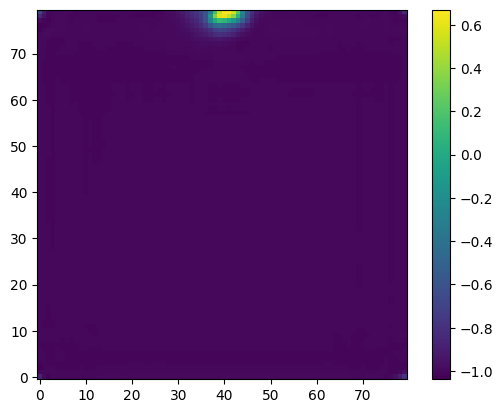

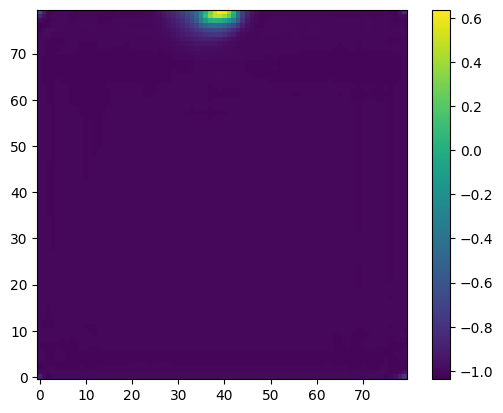

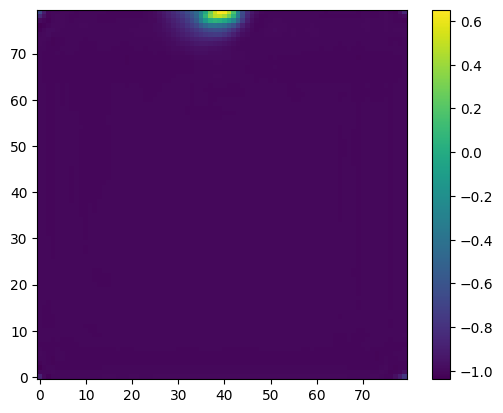

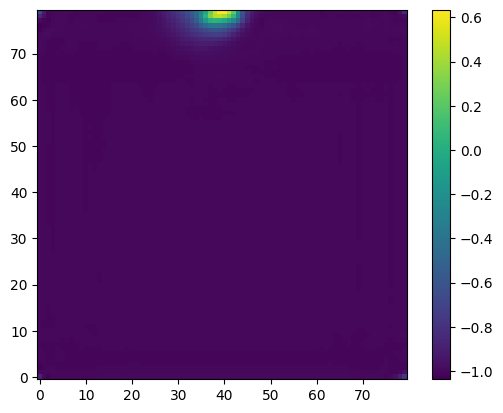

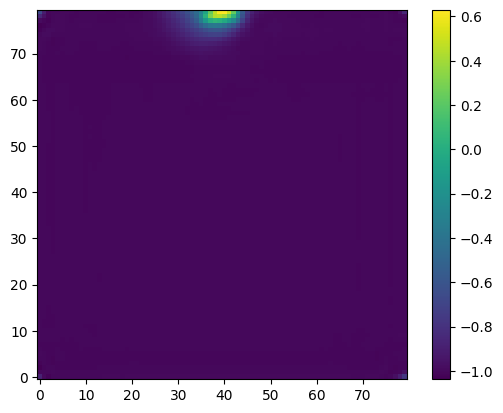

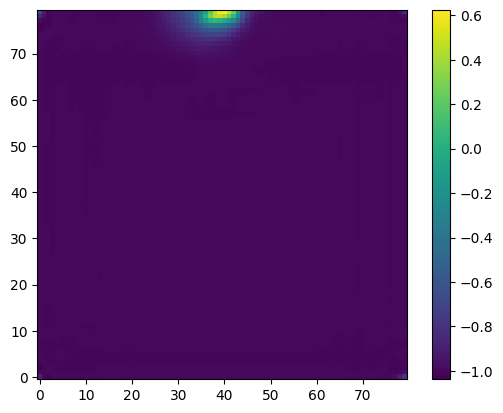

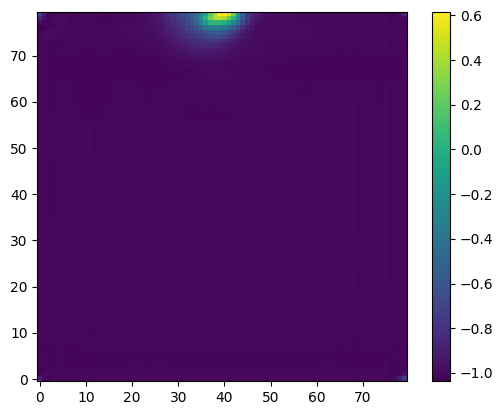

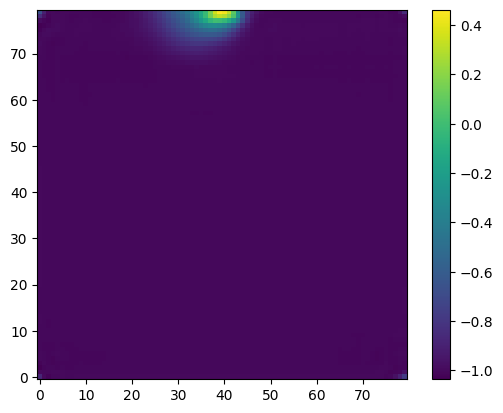

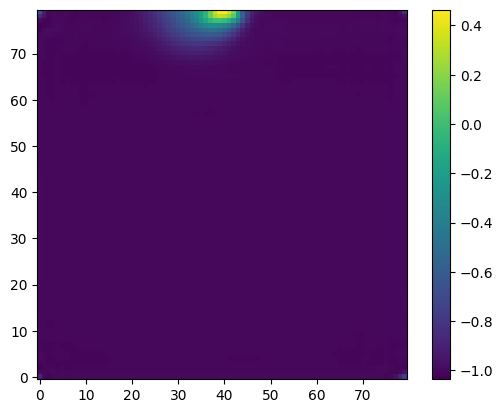

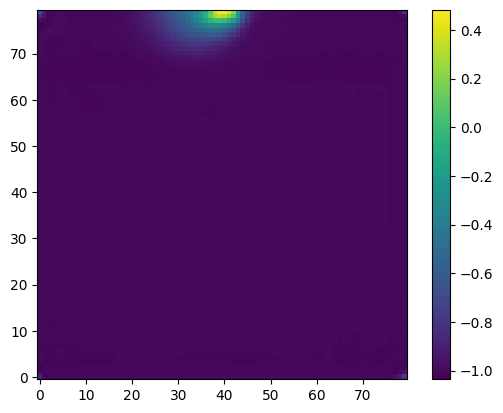

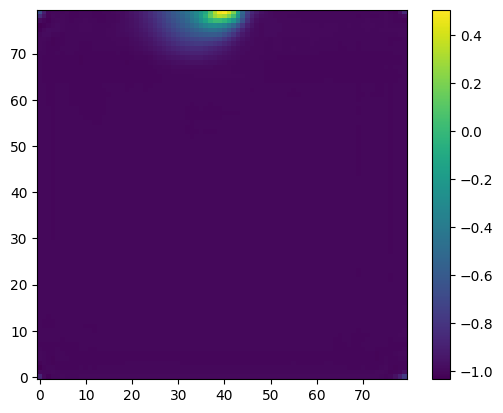

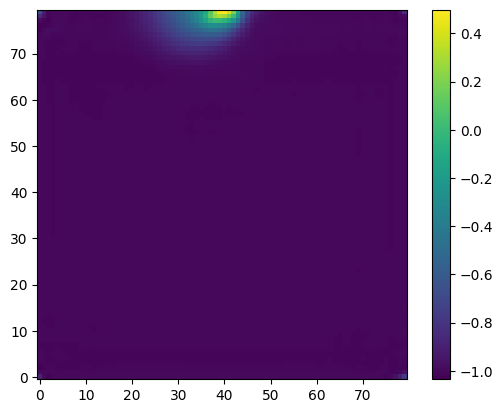

KeyboardInterrupt: 

In [14]:
# plt.imshow(lr_enc_result[0][0])
lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)
# train_dataset.normalize
for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(train_dataloader): 

    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
    plt.imshow(lr_enc(lr.to('cuda').float())[0][0].cpu().detach().numpy().T, origin = 'lower')
    # plt.imshow((lr.to('cuda').float())[0][0].cpu().detach().numpy().T, origin = 'lower')

    plt.colorbar()
    plt.show()

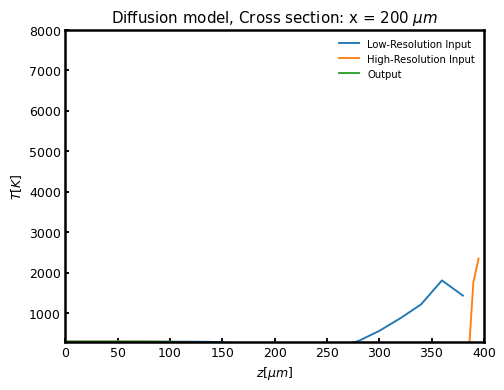

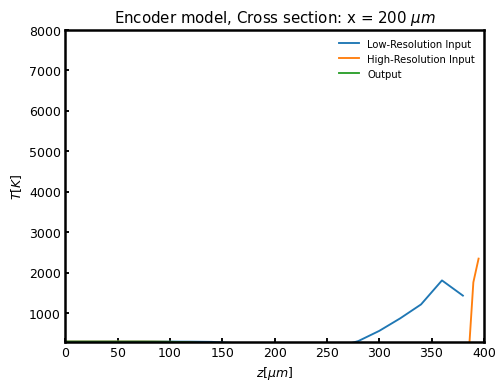

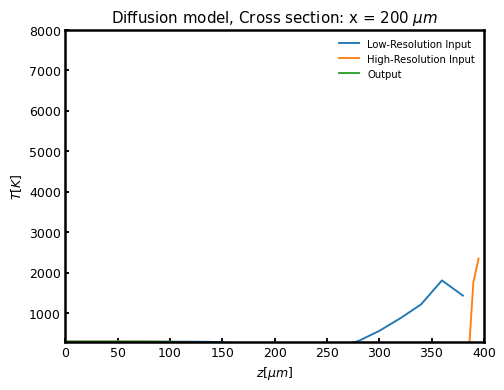

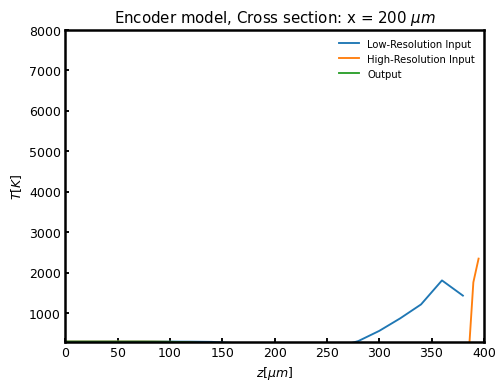

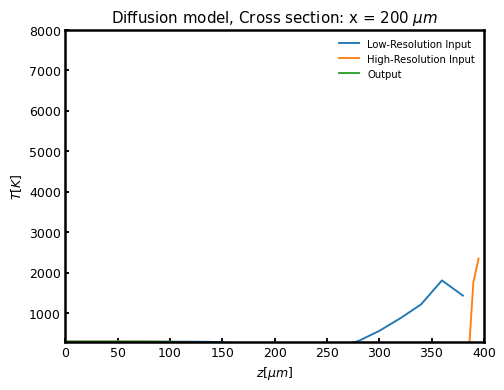

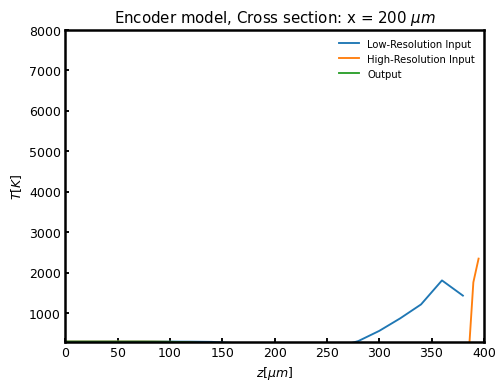

In [12]:
#### Plot temperature contours
for split, dataloader in zip(['Train', 'Validation', 'Test'], [train_dataloader, dev_dataloader, test_dataloader]):

    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dataloader.dataset)
    
    fname = os.path.join(analysis_folder, f'diffusion_temperature_line_{split}_plot_kp.png')
    plot_temp_lines(input[0,0], result_diffusion[0,0], target[0][0], split = split, modeltype = "Diffusion", save = True,fname =fname)
    # plt.savefig()
    fname = os.path.join(analysis_folder, f'encoder_temperature_line_{split}_plot_mp.png')
    plot_temp_lines(input[0,0], lr_enc_result[0][0], target[0][0], split = split, modeltype = "Encoder", save = True,fname =fname)
    # plt.savefig(os.path.join(analysis_folder, f'encoder_temperature_line_{split}_plot.png'))


In [12]:
# plt.imshow(target[0][0].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
plt.colorbar()

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

<Figure size 640x480 with 0 Axes>

In [24]:
def plot_images(input, result, target, modeltype, split = 'train', timesteps = 200, title = '', timestep = None, save =False):
    
    result  = result
    scaling_factor = 1.5
    dpi = 150
    min_temp = 293
    max_temp = 5000
    method = 'Direct'
    # os.makedirs('lrenc_saved_figures', exist_ok = True)
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.imshow(input.T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    if timestep is None:
        plt.title('[{} Data] Low Resolution, {}'.format(split, method), fontsize = 10)
    else:
        plt.title(r'[{} Data] Low Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    if save:
        plt.savefig( title + 'input.png')
    else:
        plt.show()
    # plt.show()
    plt.clf()
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((target).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.axis('off')
    # plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    plt.title(r'[{} Data] High Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/target' + title + '.png')
    if save:
        plt.savefig( title + 'target.png')
    else:
        plt.show()

    # plt.show()
    plt.clf()

    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((result).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    # plt.title('[{} Data], {} Timesteps, {} Output'.format(split,str(timesteps), modeltype), fontsize = 10)
    plt.title(r'[{} Data], {} Timesteps, {} Output, $i$ = {}'.format(split,str(timesteps), modeltype, str(timestep)), fontsize = 8)
    plt.axis('off')

    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/result'+ title + '.png')
    if save:
        plt.savefig( title + 'result.png')
    else:
        plt.show()

    # plt.show()
    plt.clf()
    plt.close('all')

In [25]:
analysis_folder

'analyzed_figures_paper_3_4/1000_implicit_linear_direct'

##### Plot melt pool images in the validation dataset. Save figures in order of power, velocity, and time.

In [38]:
last_power = ''
skip  = 50
modeltype = 'Diffusion_3_4_' # Defines part of the title of the image
verbose= False # controls how much information to print 
os.makedirs(os.path.join(analysis_folder, 'time_stepped_contours'), exist_ok = True)
for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(test_dataloader):  
    for skips in [1]:
        oldtime = time.time()
        if verbose:
            print(res.shape)

        input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
        input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
        
        # input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
        info = info[0]
        time_elapsed = time.time()-oldtime
        if verbose:
            print(info)
        if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
                timestep = 0
        else:
            timestep += 1
        folder = os.path.join(analysis_folder, 'time_stepped/'  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item()))

        os.makedirs(folder,exist_ok = True)
        title  = os.path.join(folder, 'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))))
        if verbose:
            print(title, timestep)
        plot_images(input[0], result_diffusion[0], target[0][0], timestep = timestep, split = 'Validation', modeltype =modeltype, timesteps = timesteps//skips, title =  title, save = True)
        # contour_title  = os.path.join(folder, 'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))))
        folder = os.path.join(analysis_folder, 'time_stepped_encoder/'  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item()))

        os.makedirs(folder,exist_ok = True)
        title  = os.path.join(folder, 'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))))
        if verbose:
            print(title, timestep)
        plot_images(input[0], result[0], target[0][0], timestep = timestep, split = 'Validation', modeltype ="Encoder_3_4", timesteps = timesteps//skips, title =  title, save = True)
        
        kpfname = os.path.join(analysis_folder, 'time_stepped_contours', 'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))) + f'encoder_contour_line_{split}_plot_kp.png')
        mpfname = os.path.join(analysis_folder,'time_stepped_contours',   'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))) + f'encoder_contour_line_{split}_plot_mp.png')
        # plot_srdiff_contours(input, result_diffusion, target[0], split = 'Validation', modeltype = "Encoder", save = True, kpfname = kpfname, mpfname = mpfname)

        if verbose:
            print(time_elapsed, "elapsed time")
        last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
    # if batch_idx > 4:
    #     break


#### Calculate melt pool dimensions in the validation dataset, order the results in terms of processing conditions

In [80]:
last_power = ''
modeltype = 'Diffusion' # Defines part of the title of the image
enc_depths_sim = []
diff_depths_sim = []
gt_depths_sim = []

enc_kp_sim = []
diff_kp_sim = []
gt_kp_sim = []
gt_results = {}
enc_results = {}
diff_results = {}
skip = 50
for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(train_dataloader), total = len(train_dataloader)):  
   

    oldtime = time.time()

    input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
    input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
    # input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dev_dataloader.dataset)
    info = info[0] # info is technically returned with an extra dimension, this command removes it.
    time_elapsed = time.time()-oldtime
    # print(last_power)
    if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
        
        timestep = 0

        enc_depths_sim = []
        diff_depths_sim = []
        gt_depths_sim = []

        enc_kp_sim = []
        diff_kp_sim = []
        gt_kp_sim = []

    else:
        timestep += 1
    profile_diff, kp_diff = get_profile(result_diffusion[0])
    profile_gt, kp_gt = get_profile(target[0])
    profile_enc, kp_enc = get_profile(result[0])


    enc_kp_sim.append(5*(80-np.min(kp_enc)))
    gt_kp_sim.append(5*(80-np.min(kp_gt)))
    diff_kp_sim.append(5*(80-np.min(kp_diff)))

    enc_depths_sim.append(5*(80-np.min(profile_enc)))
    gt_depths_sim.append(5*(80-np.min(profile_gt)))
    diff_depths_sim.append(5*(80-np.min(profile_diff)))

    last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
    gt_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_kp_sim
    enc_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_kp_sim
    diff_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_kp_sim
    gt_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_depths_sim
    enc_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_depths_sim
    diff_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_depths_sim
    # if batch_idx > 3:
    #     break
        # break

100%|██████████| 2970/2970 [15:14<00:00,  3.25it/s]


In [81]:
import pandas as pd
os.makedirs(os.path.join(analysis_folder, 'csv_files'), exist_ok = True)
pd.DataFrame.from_dict(gt_results).to_csv(os.path.join(analysis_folder, 'csv_files/train_gt_results.csv'))
pd.DataFrame.from_dict(enc_results).to_csv(os.path.join(analysis_folder, 'csv_files/train_enc_results.csv'))
pd.DataFrame.from_dict(diff_results).to_csv(os.path.join(analysis_folder, 'csv_files/train_diff_results.csv'))


In [50]:
np.array(diff_results)#[peaks[0]]

array({'key_power156.0vel700.0': [0, 5, 5, 5, 5, 10, 10, 10, 10, 10, 10, 15, 20, 15, 15, 20, 25, 20, 25, 20, 30, 35, 50, 45, 45, 45, 45, 40, 40, 45, 40, 45, 40, 40, 40, 40, 40, 55, 50, 45, 45, 50, 50, 50, 45, 45, 45, 45, 50, 45, 45, 45, 45, 40, 40, 50, 55, 45, 45, 50, 50, 40, 45, 50, 55, 55, 45, 55, 50, 45, 50, 55, 50, 50, 50, 50, 60, 50, 55, 55, 55, 55, 55, 50, 55, 55, 55, 50, 50, 60, 55, 55, 50, 55, 50, 55, 55, 50, 50], 'depth_power156.0vel700.0': [0, 15, 15, 15, 20, 25, 25, 25, 25, 25, 30, 30, 35, 35, 35, 35, 35, 40, 45, 45, 45, 50, 65, 60, 60, 55, 60, 60, 60, 60, 65, 60, 60, 60, 60, 65, 65, 65, 65, 65, 65, 70, 70, 70, 70, 70, 70, 75, 70, 75, 70, 70, 75, 75, 70, 70, 75, 75, 75, 75, 75, 75, 75, 80, 75, 80, 80, 75, 80, 80, 75, 80, 80, 80, 80, 80, 80, 80, 80, 85, 80, 80, 80, 80, 80, 80, 80, 80, 80, 85, 85, 85, 80, 80, 85, 80, 80, 85, 80], 'key_power183.0vel600.0': [5, 5, 5, 15, 15, 20, 25, 20, 25, 45, 70, 75, 80, 80, 65, 70, 65, 80, 75, 70, 75, 60, 75, 90, 90, 85, 105, 75, 80, 70, 75, 

##### Plot keyhole and melt pool depths over time for each power/velocity combination

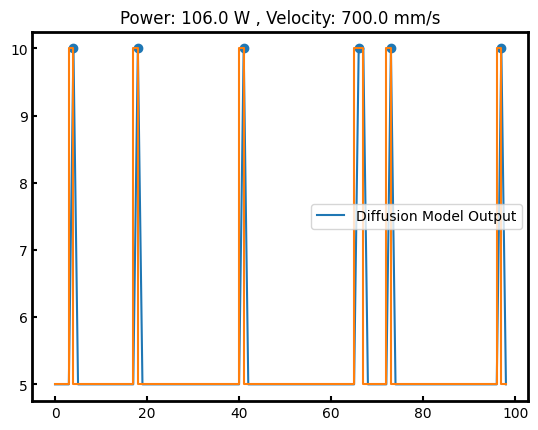

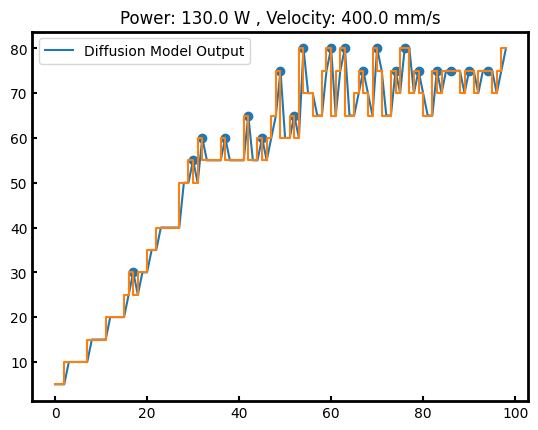

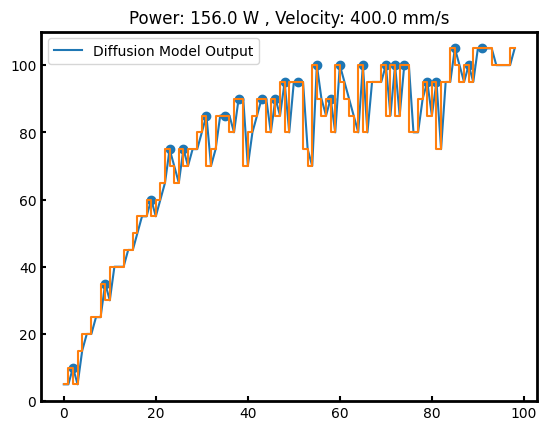

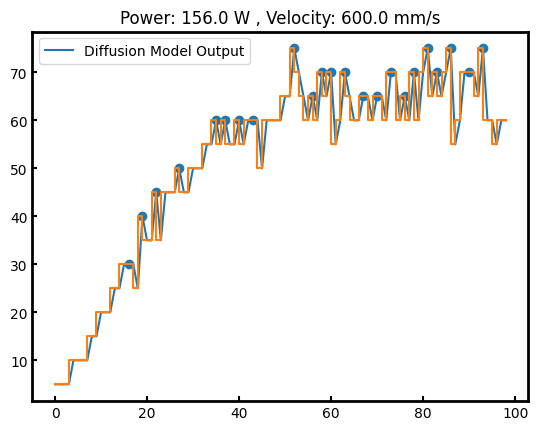

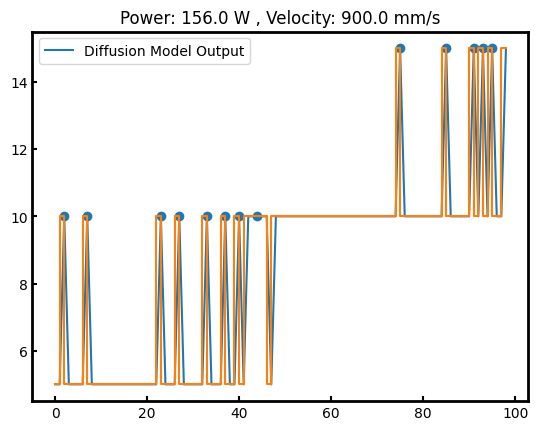

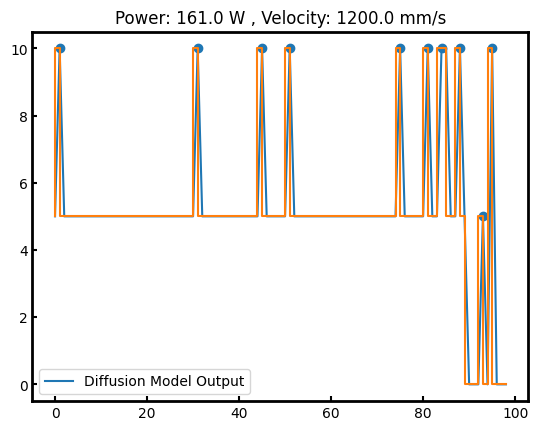

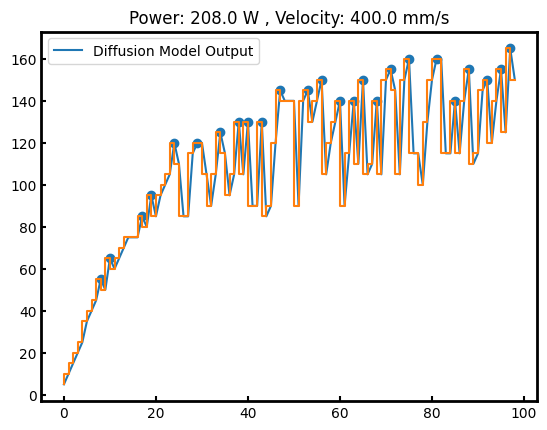

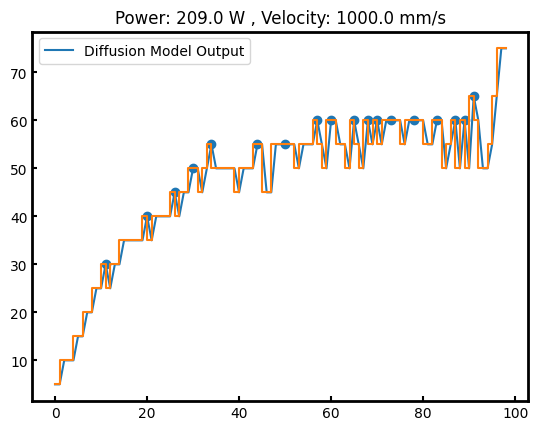

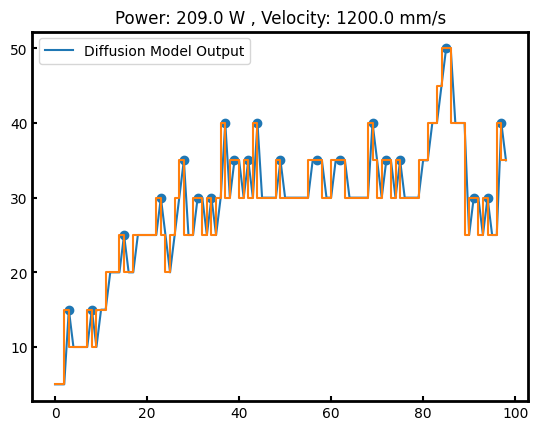

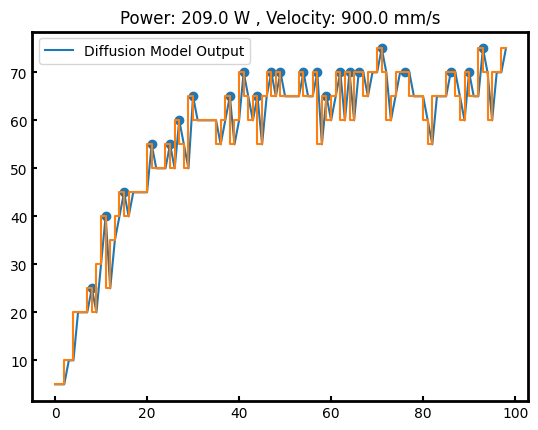

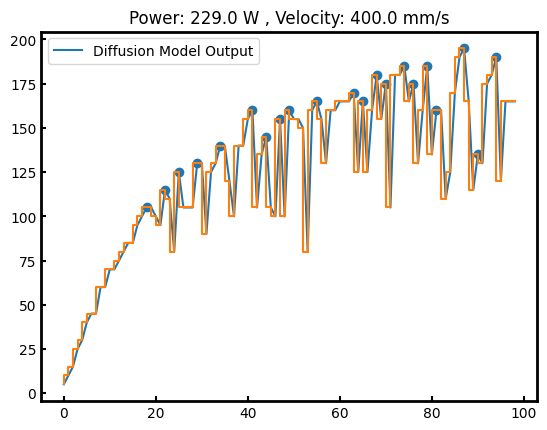

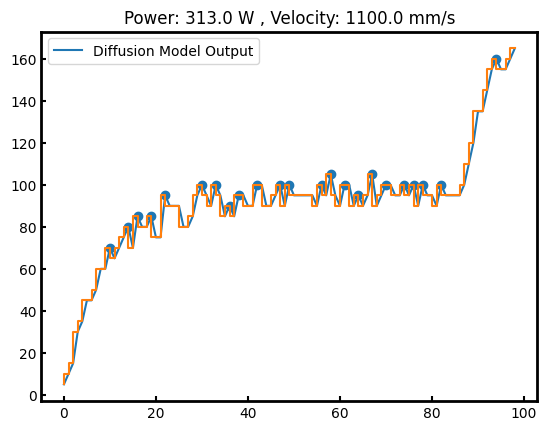

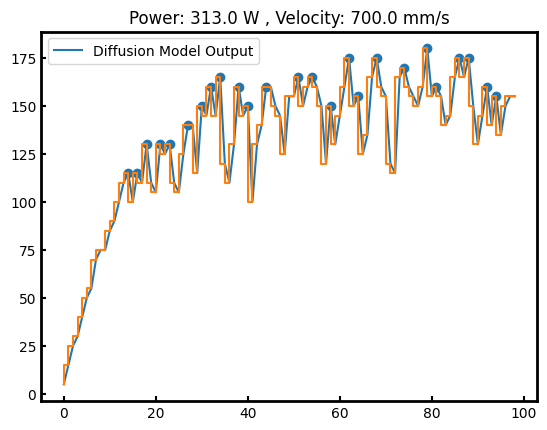

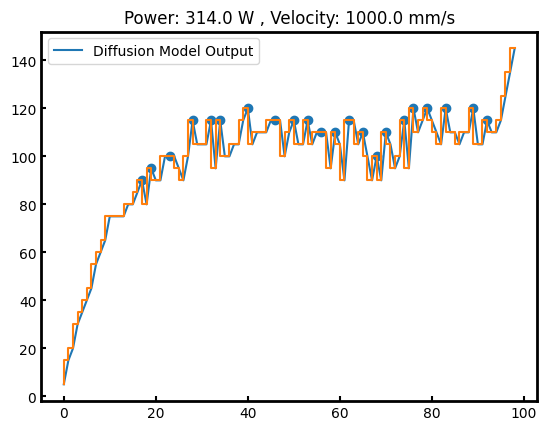

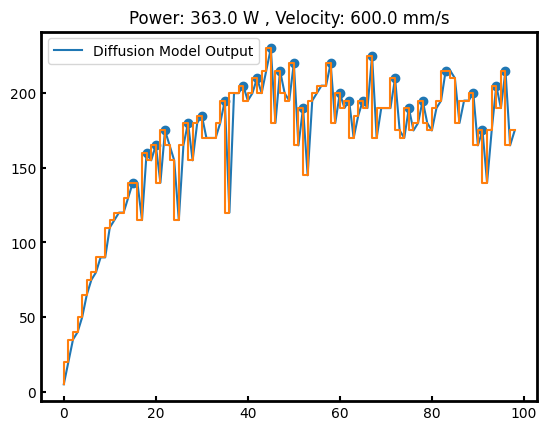

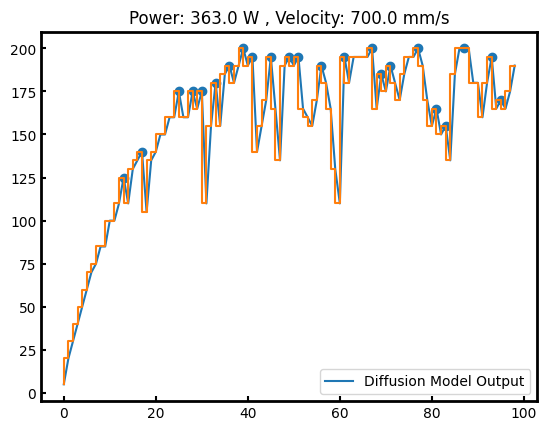

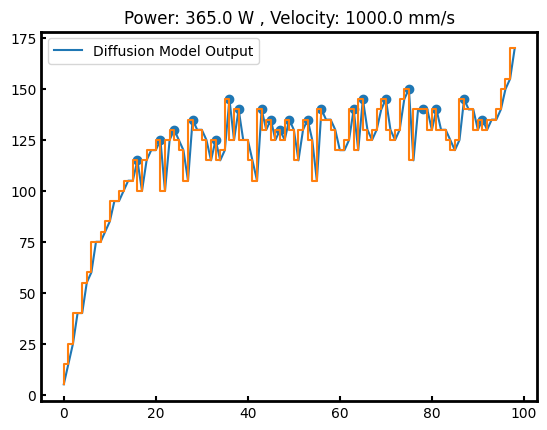

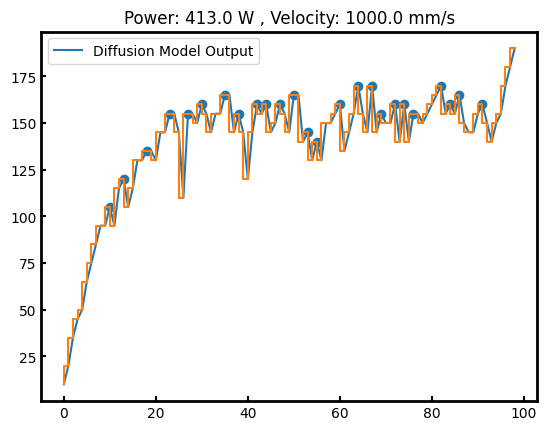

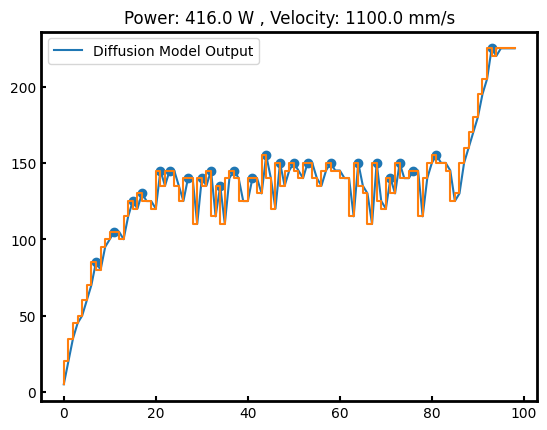

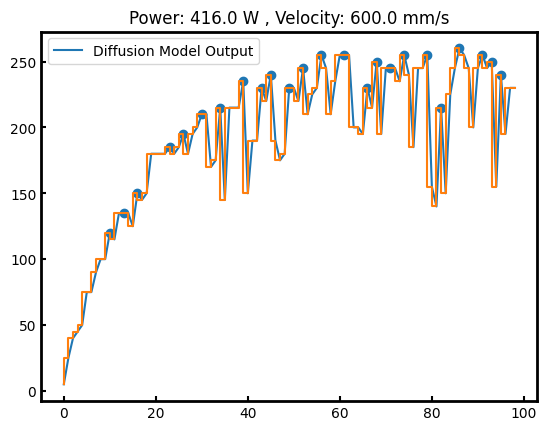

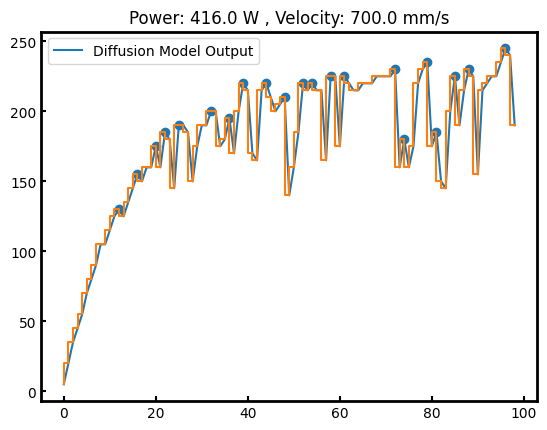

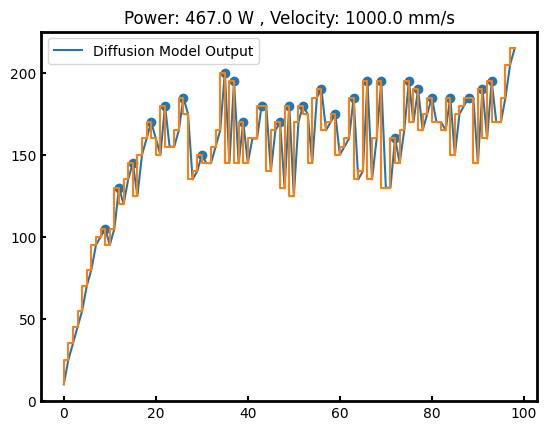

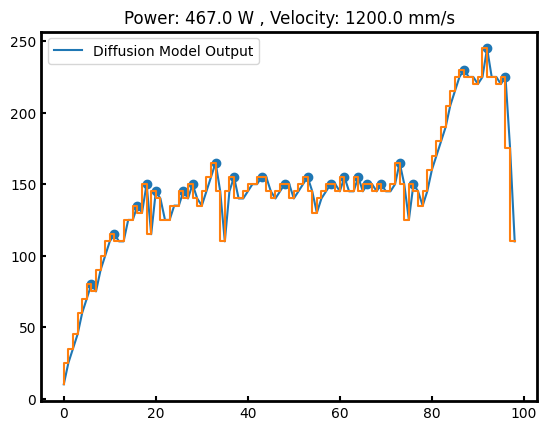

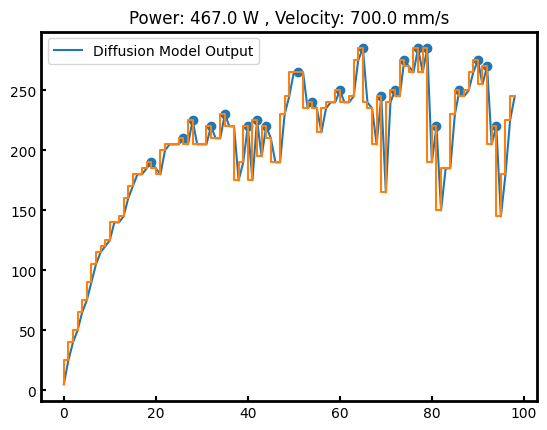

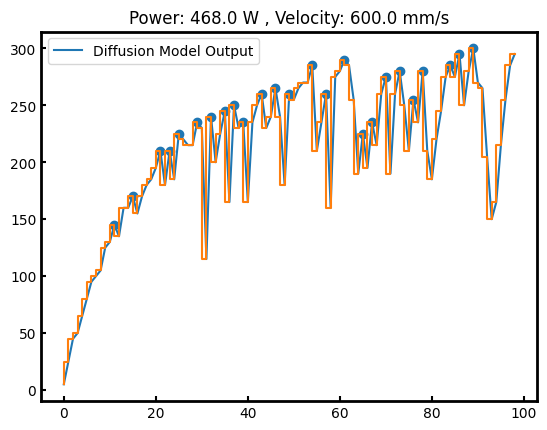

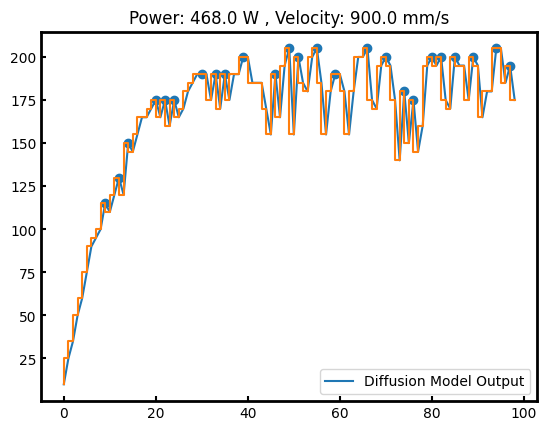

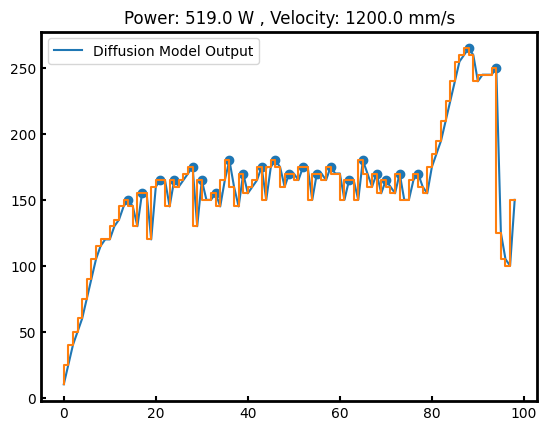

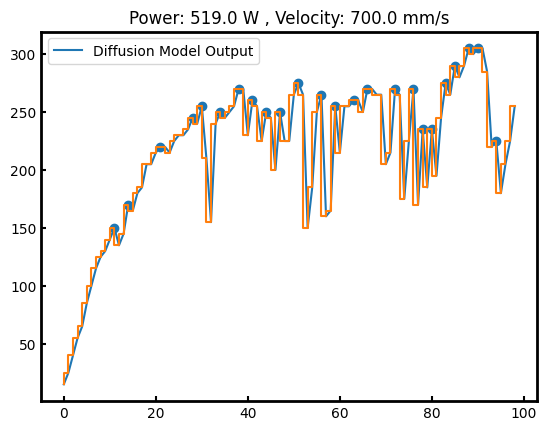

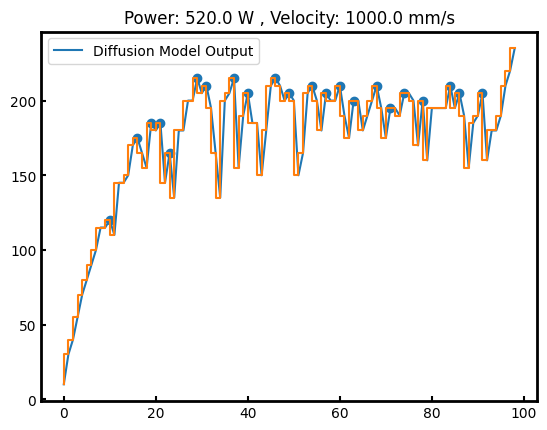

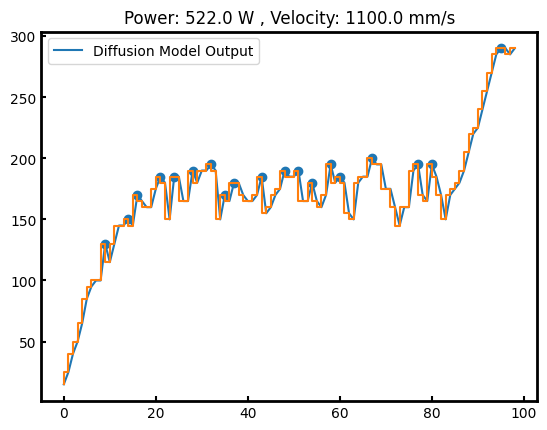

<Figure size 640x480 with 0 Axes>

In [82]:
depth_folder = os.path.join(analysis_folder, 'depth_over_time')
from peakdetect import peakdetect
from scipy.signal import find_peaks
os.makedirs(depth_folder, exist_ok = True)
for key in enc_results.keys():
    if 'key' in key:
        # plt.plot(enc_results[key], label = 'Encoder Model Output')
        plt.plot(diff_results[key], label = 'Diffusion Model Output')
        # plt.plot(gt_results[key], label = 'Ground Truth')
        power_text = key.split('power')[1].split('vel')[0]
        vel_text = key.split('vel')[1]


        
        peaks = find_peaks(diff_results[key])
        plt.scatter(peaks[0], np.array(diff_results[key])[peaks[0]])
        # peaks = peakdetect(diff_results[key]) 
        # higherPeaks = np.array(peaks[0])
        # lowerPeaks = np.array(peaks[1])
        plt.step(np.arange(99), diff_results[key])
        # plt.plot(higherPeaks[:,0], higherPeaks[:,1], 'ro', markersize = 4)
        # plt.plot(lowerPeaks[:,0], lowerPeaks[:,1], 'ko' , markersize = 4)


        plt.title(f'Power: {power_text} W , Velocity: {vel_text} mm/s')
        frame_tick()
        plt.legend()
        plt.show()
        # plt.savefig(os.path.join(depth_folder, f'{key}.png'))
        plt.clf()
        # plt.show()

In [83]:
def get_frequency(seq):
    peaks = peakdetect(seq, lookahead=1) 
    higherPeaks = np.array(peaks[0])
    lowerPeaks = np.array(peaks[1])
    print(higherPeaks)
    if len(higherPeaks) == 0:
        return 0, 0
    mask1 = higherPeaks[:,0] > 30 
    mask2 =  higherPeaks[:,0] < 80 
    indices = np.logical_and(mask1, mask2)
    frequency = 1/np.mean(np.diff(higherPeaks[indices][:,0])*5e-6)
    amp = np.std(5e-6*np.diff(higherPeaks[indices][:,0]))
    print(frequency, amp)
    return frequency, amp
def get_frequency_old(seq):
    peaks = find_peaks(seq)
    if len(peaks[0]) == 0:
        return 0, 0
    mask1 = peaks[0] > 30 
    mask2 =  peaks[0] < 80 
    indices = np.logical_and(mask1, mask2)
    frequency = 1/np.mean(np.diff(peaks[0][indices])*5e-6)
    amp = np.std(5e-6*np.diff(peaks[0][indices]))
    print(frequency, amp)
    return frequency, amp

key_power106.0vel700.0
12499.999999999998 4.4999999999999996e-05
nan nan
depth_power106.0vel700.0
key_power130.0vel400.0
55319.148936170204 3.6891011717790146e-06
55319.148936170204 5.730640163750516e-06
31249.999999999996 1.0770329614269007e-05
depth_power130.0vel400.0
key_power156.0vel400.0
51063.82978723404 5.574620066774855e-06
58333.333333333314 5.890150893739515e-06
35555.555555555555 1.4347800354061248e-05
depth_power156.0vel400.0
key_power156.0vel600.0
51063.82978723403 7.20484019407941e-06
60465.116279069756 8.85451110247795e-06
31249.999999999996 6.782329983125269e-06
depth_power156.0vel600.0
key_power156.0vel900.0
60000.0 4.714045207910318e-06
19047.619047619046 5.921359641163506e-05
46153.84615384615 4.714045207910317e-06
depth_power156.0vel900.0
key_power161.0vel1200.0
nan nan
13636.363636363634 3.681787005729088e-05
nan nan
depth_power161.0vel1200.0
key_power208.0vel400.0
58536.58536585365 5.187458165828639e-06
58536.58536585365 5.18745816582864e-06
46511.62790697673 9.75

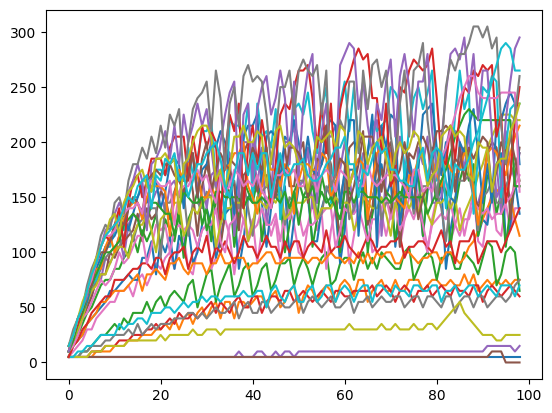

In [84]:
powers = []
vels = []
gtfreqs = []
diffreqs = []
encfreqs = []
for key in gt_results.keys():
    print(key)
    if 'key' in key:
        power = float(key.split('power')[1].split('vel')[0])
        vel = float(key.split('vel')[1])
        powers.append(power)
        vels.append(vel)
        plt.plot(gt_results[key])
        gtfreq, amp = get_frequency_old(gt_results[key])
        gtfreqs.append(gtfreq)
        diffreq, amp = get_frequency_old(diff_results[key])
        diffreqs.append(diffreq)
        encfreq, amp = get_frequency_old(enc_results[key])
        encfreqs.append(encfreq)

In [85]:
for i in range(len(gtfreqs)):
    print(gtfreqs[i], encfreqs[i], diffreqs[i])

0 nan 12499.999999999998
55319.148936170204 31249.999999999996 55319.148936170204
51063.82978723404 35555.555555555555 58333.333333333314
51063.82978723403 31249.999999999996 60465.116279069756
60000.0 46153.84615384615 19047.619047619046
nan nan 13636.363636363634
58536.58536585365 46511.62790697673 58536.58536585365
56521.73913043478 22857.14285714286 40909.090909090904
21276.595744680846 nan 49999.999999999985
49999.99999999999 27272.72727272727 63157.89473684209
49999.99999999999 46808.51063829786 53333.33333333333
52173.91304347825 7692.3076923076915 62222.222222222204
59574.468085106375 49999.99999999999 51063.82978723403
49999.99999999999 19047.619047619046 59574.468085106375
56521.73913043478 47826.08695652173 65116.27906976742
57777.77777777776 45454.54545454545 54545.454545454544
54545.45454545454 45161.29032258064 57777.77777777776
59574.468085106375 59090.90909090909 68292.68292682926
55000.0 43902.439024390245 59090.90909090909
62499.99999999999 44444.44444444444 53333.333

In [79]:
from scipy.signal import find_peaks
key = 'key_power522.0vel1100.0'
peaks,_ = find_peaks(diff_results[key])
peaks_new = peakdetect(diff_results[key], lookahead=1) 
print(peaks)
print(np.array(peaks_new[0])[:,0])
plt.plot(diff_results[key])
plt.plot(peaks, np.array(diff_results[key])[peaks], 'r.')
plt.xlim([50,80])

plt.show()
plt.plot(diff_results[key])

plt.plot(np.array(peaks_new[0])[:,0], np.array(diff_results[key])[np.array(peaks_new[0])[:,0]], 'b.')
plt.xlim([30,80])
plt.show()

KeyError: 'key_power522.0vel1100.0'

In [149]:
# diff_results[key][peaks]
peaks

array([13, 17, 19, 24, 26, 30, 33, 37, 42, 45, 49, 51, 54, 57, 59, 64, 67,
       71, 77, 80, 85, 96])

In [141]:
key

'depth_power522.0vel1100.0'

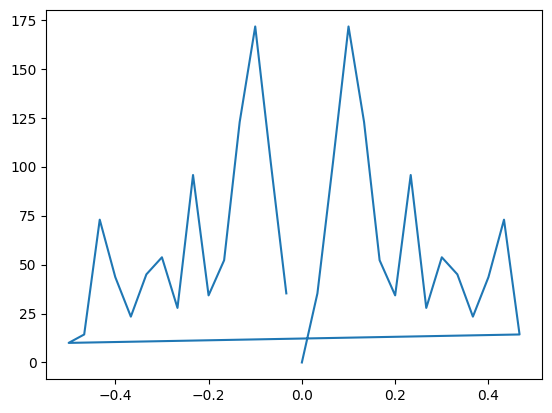

In [167]:
# plt.plot(np.fft.fft(diff_results[key][50:80]))
signal = diff_results[key][50:80] - np.mean( diff_results[key][50:80])
signal = enc_results[key][50:80] - np.mean( diff_results[key][50:80])
import numpy.fft as fft
spectrum =fft.fft(signal)
freq = fft.fftfreq(len(spectrum))
plt.plot(freq, abs(spectrum))


threshold = 0.5 * max(abs(spectrum))
mask = abs(spectrum) > threshold
peaks = freq[mask]

In [178]:
n = len(signal) # length of the signal
k = np.arange(n)
T = n#/Fs
frq = k/T # two sides frequency range
frq = frq[:len(frq)//2] # one side frequency range

Y = np.fft.fft(signal)/n # dft and normalization
Y = Y[:n//2]

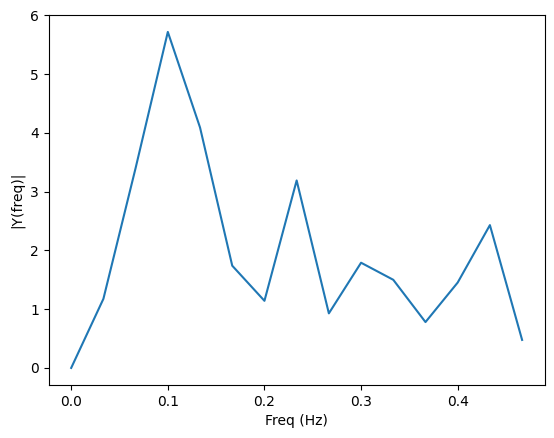

In [179]:
plt.plot(frq,abs(Y)) # plotting the spectrum
plt.xlabel('Freq (Hz)')
plt.ylabel('|Y(freq)|')
plt.show()

In [174]:
frq[np.argmax(abs(Y))]*500e6

50000000.0

In [175]:
frq

array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
       0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
       0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667])

In [112]:
from peakdetect import peakdetect

peaks = peakdetect(gt_results['key_power209.0vel700.0'], lookahead=1) 
higherPeaks = np.array(peaks[0])
lowerPeaks = np.array(peaks[1])
plt.step(np.arange(99), gt_results['key_power209.0vel700.0'])
plt.plot(higherPeaks[:,0], higherPeaks[:,1], 'ro', markersize = 4)
plt.plot(lowerPeaks[:,0], lowerPeaks[:,1], 'ko' , markersize = 4)

KeyError: 'key_power209.0vel700.0'

In [121]:
def get_frequency(seq):
    peaks = peakdetect(seq, lookahead=1) 
    higherPeaks = np.array(peaks[0])
    lowerPeaks = np.array(peaks[1])
    print(higherPeaks)
    if len(higherPeaks) == 0:
        return 0, 0
    mask1 = higherPeaks[:,0] > 50 
    mask2 =  higherPeaks[:,0] < 80 
    indices = np.logical_and(mask1, mask2)
    frequency = 1/np.mean(np.diff(higherPeaks[indices][:,0])*5e-6)
    amp = np.std(5e-6*np.diff(higherPeaks[indices][:,0]))
    print(frequency, amp)
    return frequency, amp
    # plt.step(np.arange(99), gt_results['key_power209.0vel700.0'])
    # plt.plot(higherPeaks[:,0], higherPeaks[:,1], 'ro', markersize = 4)
    # plt.plot(lowerPeaks[:,0], lowerPeaks[:,1], 'ko' , markersize = 4)

In [32]:
mask = higherPeaks[:,0] > 50 
1/np.mean(np.diff(higherPeaks[higherPeaks[:,0] > 50][:,0])*5e-6)

43902.43902439024

In [76]:
gt_results#[key]

{'key_power209.0vel900.0': [60, 40],
 'depth_power209.0vel900.0': [90, 55],
 'key_power519.0vel700.0': [295],
 'depth_power519.0vel700.0': [315],
 'key_power229.0vel400.0': [105],
 'depth_power229.0vel400.0': [130],
 'key_power314.0vel1000.0': [100],
 'depth_power314.0vel1000.0': [130],
 'key_power413.0vel1000.0': [170],
 'depth_power413.0vel1000.0': [180],
 'key_power363.0vel600.0': [155],
 'depth_power363.0vel600.0': [220],
 'key_power467.0vel1000.0': [195, 175],
 'depth_power467.0vel1000.0': [205, 200],
 'key_power156.0vel900.0': [10],
 'depth_power156.0vel900.0': [30],
 'key_power416.0vel700.0': [135],
 'depth_power416.0vel700.0': [150],
 'key_power365.0vel1000.0': [130],
 'depth_power365.0vel1000.0': [160],
 'key_power313.0vel700.0': [100],
 'depth_power313.0vel700.0': [180],
 'key_power156.0vel600.0': [65],
 'depth_power156.0vel600.0': [85],
 'key_power209.0vel1200.0': [30],
 'depth_power209.0vel1200.0': [50],
 'key_power467.0vel1200.0': [150],
 'depth_power467.0vel1200.0': [175]

key_power106.0vel700.0
[]
[[43 10]
 [59 10]
 [79 10]]
10000.0 0.0
[[17 10]]
nan nan
depth_power106.0vel700.0
key_power130.0vel400.0
[[21 35]
 [26 45]
 [32 55]
 [38 55]
 [42 60]
 [49 70]
 [53 65]
 [57 65]
 [61 70]
 [68 75]
 [74 75]
 [80 75]
 [86 80]
 [91 75]]
38095.23809523809 6.495190528383291e-06
[[ 5 10]
 [ 9 15]
 [17 35]
 [25 40]
 [30 50]
 [37 60]
 [43 65]
 [48 65]
 [54 65]
 [62 80]
 [69 80]
 [77 80]
 [87 75]
 [92 80]]
26086.95652173913 2.3570226039551584e-06
[[ 8 15]
 [17 30]
 [29 50]
 [39 60]
 [48 65]
 [56 70]
 [60 70]
 [89 75]
 [95 75]]
49999.99999999999 0.0
depth_power130.0vel400.0
key_power156.0vel400.0
[[ 10  35]
 [ 17  55]
 [ 23  65]
 [ 27  75]
 [ 31  85]
 [ 35  90]
 [ 39  90]
 [ 43  90]
 [ 48  95]
 [ 52  85]
 [ 56 100]
 [ 60  95]
 [ 66  95]
 [ 74 105]
 [ 78 100]
 [ 83 100]
 [ 87  95]
 [ 91 110]
 [ 96 105]]
38461.53846153846 8.000000000000001e-06
[[ 10  35]
 [ 17  55]
 [ 25  70]
 [ 35  85]
 [ 47 100]
 [ 52  85]
 [ 57  80]
 [ 64 100]
 [ 70  95]
 [ 76  90]
 [ 85 105]
 [ 91 110]

/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


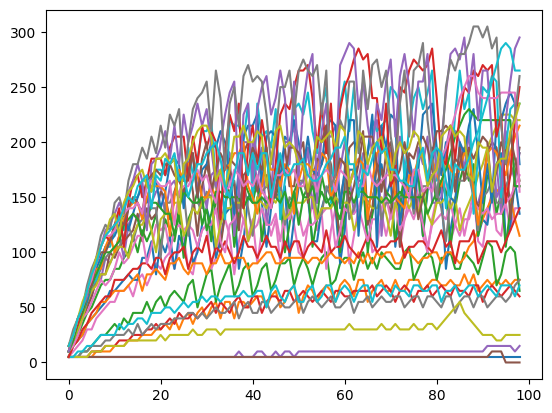

In [122]:
powers = []
vels = []
gtfreqs = []
diffreqs = []
encfreqs = []
for key in gt_results.keys():
    print(key)
    if 'key' in key:
        power = float(key.split('power')[1].split('vel')[0])
        vel = float(key.split('vel')[1])
        powers.append(power)
        vels.append(vel)
        plt.plot(gt_results[key])
        gtfreq, amp = get_frequency(gt_results[key])
        gtfreqs.append(gtfreq)
        diffreq, amp = get_frequency(diff_results[key])
        diffreqs.append(diffreq)
        encfreq, amp = get_frequency(enc_results[key])
        encfreqs.append(encfreq)
    # frequency.append()

In [88]:
from scipy import interpolate
grid_x, grid_y = np.meshgrid((np.arange(np.min(powers), np.max(powers))), np.arange(np.min(vels), np.max(vels)))
gtfreq_grid = interpolate.griddata((powers, vels), gtfreqs, (grid_x, grid_y))
diffreq_grid = interpolate.griddata((powers, vels), diffreqs, (grid_x, grid_y))
encfreq_grid = interpolate.griddata((powers, vels), encfreqs, (grid_x, grid_y))



In [119]:
diff_model.epoch

AttributeError: 'DiffusionModel' object has no attribute 'epoch'

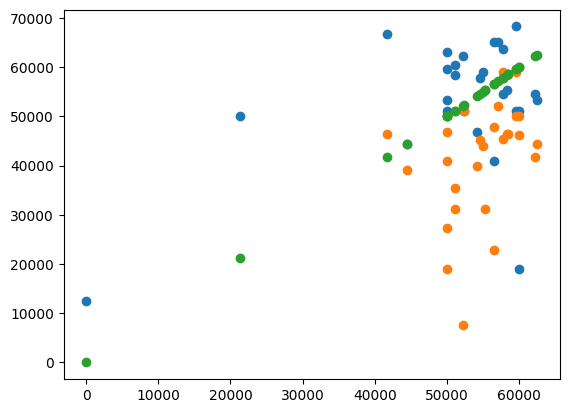

In [86]:
# np.min(vels)
# plt.hist(gtfreq_grid)
plt.scatter(gtfreqs, diffreqs)
plt.scatter(gtfreqs, encfreqs)
plt.scatter(gtfreqs, gtfreqs)

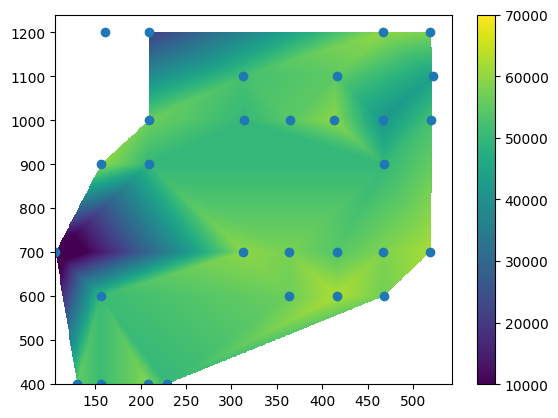

In [93]:
plt.pcolormesh(grid_x, grid_y,gtfreq_grid, vmin = 10000, vmax = 70000)
plt.colorbar()
plt.scatter(powers, vels)

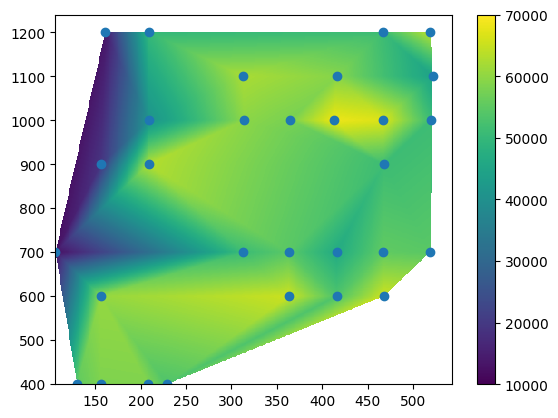

In [92]:
plt.pcolormesh(grid_x, grid_y,diffreq_grid, vmin = 10000, vmax = 70000)
plt.colorbar()
plt.scatter(powers, vels)

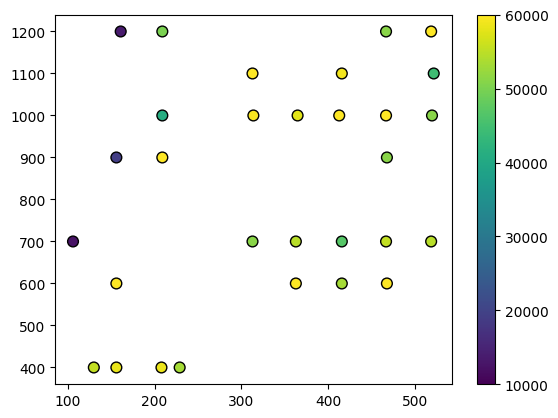

In [114]:
# plt.pcolormesh(grid_x, grid_y,encfreq_grid)
plt.scatter(powers, vels, c = diffreqs, edgecolors='k', s = 60, vmin = 10000, vmax = 60000)
plt.colorbar()

In [112]:
# encfreqs
nanreplace_encfreqs = np.copy(encfreqs)
nanreplace_encfreqs[np.isnan(encfreqs)] = 0

nanreplace_diffreqs = np.copy(diffreqs)
nanreplace_diffreqs[np.isnan(diffreqs)] = 0


nanreplace_gtfreqs = np.copy(gtfreqs)
nanreplace_gtfreqs[np.isnan(gtfreqs)] = 0


In [155]:
np.isnan(nanreplace_gtfreqs)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

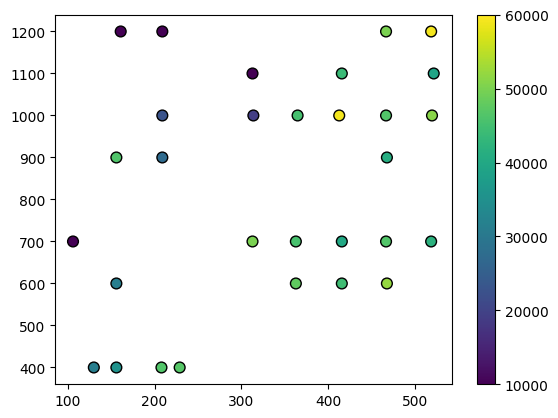

In [115]:
plt.scatter(powers, vels, c = nanreplace_encfreqs, edgecolors='k', s = 60, vmin = 10000, vmax = 60000)
plt.colorbar()

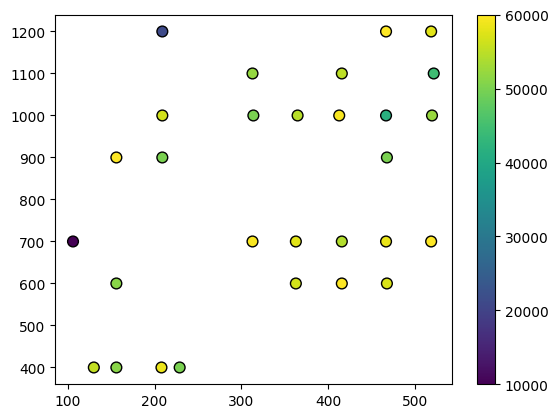

In [116]:
plt.scatter(powers, vels, c = gtfreqs, edgecolors='k', s = 60, vmin = 10000, vmax = 60000)
plt.colorbar()

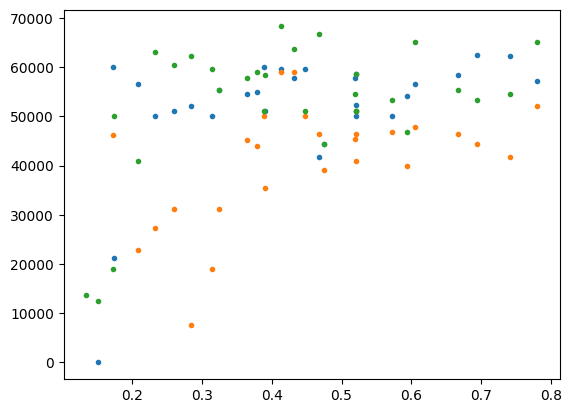

In [119]:
plt.plot(np.array(powers)/np.array(vels), gtfreqs, '.')
plt.plot(np.array(powers)/np.array(vels), encfreqs, '.')
plt.plot(np.array(powers)/np.array(vels), diffreqs, '.')



In [153]:
np.array(gtfreqs)[digitized_density == 0]# diffmeans


array([    0.        , 60000.        ,            nan, 21276.59574468])

<ErrorbarContainer object of 3 artists>

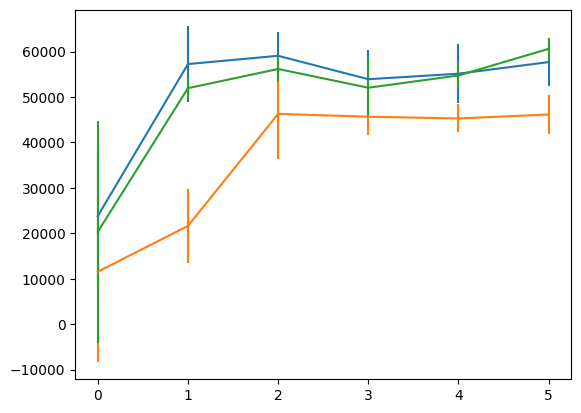

In [157]:
plt.errorbar(np.arange(6), diffmeans, diffstds)
plt.errorbar(np.arange(6), encmeans, encstds)
plt.errorbar(np.arange(6), gtmeans, gtstds)



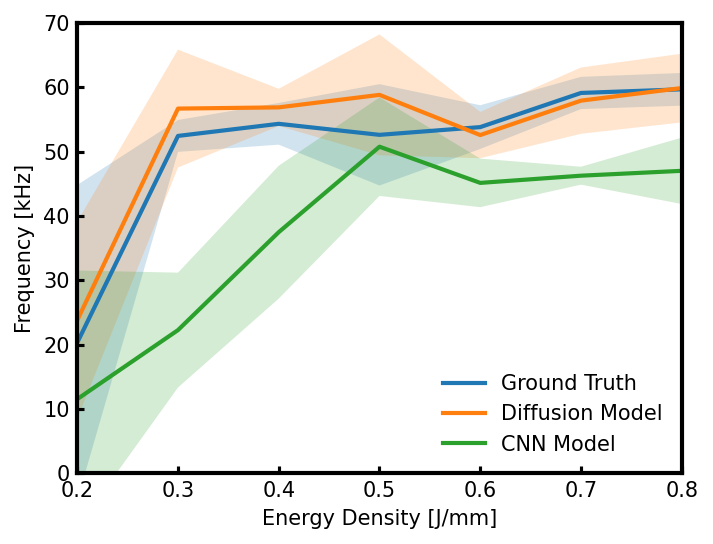

In [210]:
bins = np.linspace(0.2,0.8, 7 )
gtmeans = []
gtstds = []
diffmeans = []
diffstds = []
encmeans = []
encstds = []
digitized_density = np.digitize(np.array(powers)/np.array(vels), bins)
for idx, bin in enumerate(bins):
    gtarray = np.array(nanreplace_gtfreqs)[digitized_density == idx]/1000
    diffarray = np.array(nanreplace_diffreqs)[digitized_density == idx]/1000
    encarray = np.array(nanreplace_encfreqs)[digitized_density == idx]/1000

    gtmean = np.mean(gtarray)
    encmean = np.mean(encarray)
    diffmean = np.mean(diffarray)

    gtstd = np.std(gtarray)
    encstd = np.std(encarray)
    diffstd = np.std(diffarray)

    gtstd = np.std(gtarray)
    gtmean = np.mean(gtarray)
    encstd = np.std(encarray)
    encmean = np.mean(encarray)
    diffstd = np.std(diffarray)
    diffmean = np.mean(diffarray)

    gtmeans.append(gtmean)
    gtstds.append(gtstd)


    encmeans.append(encmean)
    encstds.append(encstd)
    diffmeans.append(diffmean)
    diffstds.append(diffstd)
# np.digitize(np.array(powers)/np.array(vels), bins
# )
encmeans = np.array(encmeans)
encstds = np.array(encstds)
diffmeans = np.array(diffmeans)
diffstds = np.array(diffstds)
gtmeans = np.array(gtmeans)
gtstds = np.array(gtstds)
# plt.plot(gtmeans+gtstds)
# plt.plot(gtmeans-gtstds)

# plt.plot(diffmeans)
import scipy
from scipy import interpolate
interpstds = interpolate.interp1d(np.arange(len(bins)), gtstds)
interpmeans = interpolate.interp1d(np.arange(len(bins)), gtmeans)
plt.figure(dpi= 150, figsize = np.array([4,3])*1.3)
# interp_length = 10
# interp_array = np.linspace(0, len(bins) -1 , interp_length)
# plt.fill_between(interp_array, interpmeans(interp_array) - interpstds(interp_array), interpmeans(interp_array) + interpstds(interp_array), alpha = 0.5)
# plt.fill_between(interp_array, interpmeans(interp_array) - interpstds(interp_array), interpmeans(interp_array) + interpstds(interp_array), alpha = 0.5)

plt.plot(bins,gtmeans, label = 'Ground Truth', linewidth = 2.0)
plt.plot(bins,diffmeans, label = 'Diffusion Model', linewidth = 2.0)
plt.plot(bins,encmeans, label = 'CNN Model', linewidth = 2.0)


plt.fill_between(bins,gtmeans- gtstds, gtmeans+gtstds, alpha = 0.2)
plt.fill_between(bins,  diffmeans- diffstds, diffmeans+diffstds, alpha = 0.2)
plt.fill_between(bins, encmeans- encstds, encmeans+encstds, alpha = 0.2)
# plt.xlim()
frame_tick()
plt.legend(frameon = False, loc= 'lower right')
plt.xlim([0.2, 0.8])
plt.ylim([0, 70])
plt.ylabel('Frequency [kHz]')
plt.xlabel('Energy Density [J/mm]')
plt.show()

In [125]:
gtfreqs

[0,
 55319.148936170204,
 51063.82978723404,
 51063.82978723403,
 60000.0,
 nan,
 58536.58536585365,
 56521.73913043478,
 21276.595744680846,
 49999.99999999999,
 49999.99999999999,
 52173.91304347825,
 59574.468085106375,
 49999.99999999999,
 56521.73913043478,
 57777.77777777776,
 54545.45454545454,
 59574.468085106375,
 55000.0,
 62499.99999999999,
 54166.66666666666,
 41666.66666666666,
 59999.999999999985,
 58333.33333333333,
 57142.85714285712,
 49999.999999999985,
 57777.77777777776,
 62222.222222222204,
 52380.952380952374,
 44444.444444444445]

In [176]:
np.linspace(0, len(bins), interp_length)

array([0.        , 0.36842105, 0.73684211, 1.10526316, 1.47368421,
       1.84210526, 2.21052632, 2.57894737, 2.94736842, 3.31578947,
       3.68421053, 4.05263158, 4.42105263, 4.78947368, 5.15789474,
       5.52631579, 5.89473684, 6.26315789, 6.63157895, 7.        ])

#### Calculate melt pool/keyhole dimensions for DDIM sampler for varying number of timesteps

In [ ]:
run_skip_ablation = False
if run_skip_ablation:
    max_depth_gt = []
    max_depth_input = []
    kp_depth_gt = []
    kp_depth_input = []
    kp_depth_diffs = []
    max_depth_diffs = []
    psnrs_lr = []
    psnrs_diff= []

    ssims_diff = []
    ssims_lr = []

    l1_lr = []
    l1_diff = []

    sample_times = []
    steps_list= []
    psnr_mean_lr = []
    ssim_mean_lr = []
    l1_mean_lr = []
    ssim_mean_diff = []
    psnr_mean_diff = []
    l1_mean_diff = []
    l1loss = nn.L1Loss()
    factor = 2
    mesh_hr = 5
    mesh_lr = 20

    for skips in [1, 2, 3, 5, 10, 15, 20, 50]:
        diff_steps = diff_model.timesteps
        kp_depth_diff = []
        max_depth_diff = []
        max_depth_input= []
        kp_depth_input = []
        max_depth_gt  = []
        kp_depth_gt = []
        psnr_batches_lr = []
        psnr_batches_diff = []
        l1_batches_diff = []
        l1_batches_lr = []
        ssim_batches_lr = []
        ssim_batches_diff = []

        for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(dev_dataloader):  
            oldtime = time.time()
            input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
            # input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
            upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
            lrpsnr = PSNR(upscale, target, target.shape[0]).item()

            diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()
            psnr_batches_diff.append(diffpsnr)
            psnr_batches_lr.append((lrpsnr))
            lrssim = SSIM(upscale, target.view(upscale.shape), target.shape[0])
            diffssim = SSIM(result_diffusion, target.view(upscale.shape), target.shape[0])
            lrl1 = l1loss(upscale, target)
            diffl1 = l1loss(torch.tensor(result_diffusion), target)
            ssim_batches_lr.append(lrssim)
            ssim_batches_diff.append(diffssim)
            l1_batches_lr.append(lrl1)
            l1_batches_diff.append(diffl1)
            for i, rd in enumerate(result_diffusion):
                elapsed = time.time() - oldtime
                if batch_idx == 0:
                    sample_times.append(elapsed)
                    steps_list.append(timesteps//skips)
                profile_diff, kp_diff = get_profile(result_diffusion[i])
                profile_gt, kp_gt = get_profile(target[i])
                profile_input, kp_input = get_profile(input[i], mesh = 20)

                max_depth_gt.append(mesh_hr*(20*factor-5*factor - np.min(profile_gt)))
                max_depth_diff.append(mesh_hr*(20*factor-5*factor  -np.min(profile_diff)))
                max_depth_input.append(mesh_lr*(20-5- np.min(profile_input)))
                kp_depth_gt.append(mesh_hr*(20*factor-5*factor-np.min(kp_gt)))
                kp_depth_input.append(mesh_lr*(20-5-np.min(kp_input)))
                kp_depth_diff.append(mesh_hr*(20*factor-5*factor-np.min(kp_diff)))
                
        kp_depth_diffs.append(kp_depth_diff)
        max_depth_diffs.append(max_depth_diff)
        ssims_diff.append(ssim_batches_diff)
        ssims_lr.append(ssim_batches_lr)
        l1_lr.append(l1_batches_lr)
        psnrs_lr.append(psnr_batches_lr)
        psnrs_diff.append(psnr_batches_diff)
        l1_diff.append(l1_batches_diff)
        psnr_mean_lr.append(np.mean(psnr_batches_lr))
        psnr_mean_diff.append(np.mean(psnr_batches_diff))
        ssim_mean_diff.append(np.mean(ssim_batches_diff))
        ssim_mean_lr.append(np.mean(ssim_batches_lr))
        l1_mean_lr.append(np.mean(l1_batches_lr))
        l1_mean_diff.append(np.mean(l1_batches_diff))
        

### Calculate melt pool and keyhole dimensions

In [ ]:
def get_inst_profile(image, mesh = 5):
    image = image[0].T
    print(image.shape)
    binarized = image > 1900
    profile = []
    keyholeprofile = []
    for i in range(binarized.shape[1]):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:
            profile.append(np.min(coords))
            keyholeprofile.append(np.max(coords))
        else:
            profile.append(binarized.shape[1])
            keyholeprofile.append(binarized.shape[1])
    profile = np.array(profile)
    keyholeprofile = np.array(keyholeprofile)
    return(profile, keyholeprofile)

#### Plot melt pool statistics

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
if run_skip_ablation:
    plt.figure(figsize = [4,3], dpi = 150)
    plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
    plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
    maes_depth = []
    for max_depth, skips in zip(max_depth_diffs, [1, 2, 3, 5, 10, 15, 20, 50]):
        plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(timesteps//skips))
    
        mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
        mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
        maes_depth.append(mae_depth_diff)
        print(mae_depth_diff, max_depth)
        
        plt.xlim(0,300)
        plt.ylim(0,300)
        frame_tick()
    plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
    plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
    plt.title('Validation Set')
    plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
    plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
    plt.legend(fontsize = 5, loc = 'lower right')
    plt.show()

#### Plot keyhole statistics

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
if run_skip_ablation:

    plt.figure(figsize = [4,3], dpi = 150)
    plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
    plt.scatter(max_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
    maes_depth = []
    for kp_depth, skips in zip(kp_depth_diffs, [1, 2, 3, 5, 10, 15, 20, 50]):
        plt.scatter(kp_depth_gt, kp_depth, s = 3.0, label = 'Super Resolution, {}'.format(timesteps//skips))
    
        mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
        mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth)
        maes_depth.append(mae_depth_diff)
    
        plt.xlim(0,300)
        plt.ylim(0,300)
        frame_tick()
        print(maes_depth)
        
    plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
    plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
    plt.title('Validation Set')
    plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
    plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
    plt.legend(fontsize = 5, loc = 'lower right')
    plt.show()

In [ ]:
if run_skip_ablation:

    plt.plot(steps_list[::12], maes_depth, '.')
    frame_tick()
    plt.xlabel('Sampling Timesteps')
    plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
    plt.show()
    frame_tick()

    plt.plot(steps_list[::12], sample_times[::12], '.')
    plt.xlabel('Sampling Timesteps')
    plt.ylabel(r'Elapsed Time (s)')
    plt.show()


    plt.plot(steps_list[::12], maes_depth, '.')
    frame_tick()
    plt.xlabel('Sampling Timesteps')
    plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
    plt.show()
    frame_tick()


In [34]:


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a



def predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, encoding, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if encoding:
            # x_e = forwardpass(lr_enc, lr.to(device).float(), factor = train_dataset.factor)
        if len(lr.shape)< 4:
            x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float())
        else:
            x_e = forwardpass(lr_enc, lr.to(device).float())
    else:
        x_e = upscaled_lr.to(device).float().repeat(1,1,1, 1)
    
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    # with torch.no_grad():
    #     n = img.size(0)
    #     seq_next = [-1] + list(seq[:-1])
    #     x0_preds = []
        
    #     x = torch.randn(shape, device=device)
    #     xs = [x]
    #     for i, j in zip(reversed(seq), reversed(seq_next)):
    #         t = (torch.ones(n) * i).to(x.device)
    #         next_t = (torch.ones(n) * j).to(x.device)
    #         at = compute_alpha(b, t.long())
    #         at_next = compute_alpha(b, next_t.long())
    #         xt = xs[-1].to('cuda')
    #         et = model(x, t, x_e)#model(xt, t)
    #         x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
    #         x0_preds.append(x0_t.to('cpu'))
    #         c1 = (
    #             kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
    #         )
    #         c2 = ((1 - at_next) - c1 ** 2).sqrt()
    #         xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
    #         xs.append(xt_next.to('cpu'))
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 

    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b



#### Calculate the melt pool/keyhole dimensions for a single value of DDIM sampling timesteps

In [29]:
max_depth_gt = []
max_depth_input = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
sample_times = []
steps_list= []
skip  = 100
mesh_hr = 5
factor =4 
mesh_lr = 20
kp_depth_diff = []
max_depth_diff = []
max_depth_input= []
kp_depth_input = []
max_depth_gt  = []
kp_depth_gt = []
max_depth_enc = []
kp_depth_enc = []
kp_depth_encs =[]
max_depth_encs = []
encode_bool = True 
for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(train_dataloader), total = len(train_dataloader)):  
    oldtime = time.time()
    # input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset, skip = skip)
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)

    input, result_diffusion, target, xs, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')

    for i, rd in enumerate(result_diffusion):
        elapsed = time.time() - oldtime
        if batch_idx == 0:
            sample_times.append(elapsed)
            steps_list.append(timesteps//skip)
        profile_diff, kp_diff = get_profile(result_diffusion[i])
        profile_gt, kp_gt = get_profile(target[i])
        profile_input, kp_input = get_profile(input[i], mesh = 20)
        profile_enc, kp_enc = get_profile(lr_enc_result[i])
        max_depth_gt.append(mesh_hr*(20*factor - np.min(profile_gt)))
        max_depth_diff.append(mesh_hr*(20*factor  -np.min(profile_diff)))
        max_depth_enc.append(mesh_hr*(20*factor - np.min(profile_enc)))
        max_depth_input.append(mesh_lr*(20 - np.min(profile_input)))
        kp_depth_gt.append(mesh_hr*(20*factor-np.min(kp_gt)))
        kp_depth_input.append(mesh_lr*(20-np.min(kp_input)))
        kp_depth_diff.append(mesh_hr*(20*factor-np.min(kp_diff)))
        kp_depth_enc.append(mesh_hr*(20*factor -np.min(kp_enc)))
 
kp_depth_diffs.append(kp_depth_diff)
max_depth_diffs.append(max_depth_diff)
kp_depth_encs.append(kp_depth_enc)
max_depth_encs.append(max_depth_enc)
print(kp_depth_diffs)

100%|██████████| 2970/2970 [08:38<00:00,  5.73it/s]

[[0, 30, 0, 55, 25, 360, 35, 235, 5, 360, 70, 130, 15, 5, 365, 120, 35, 25, 115, 90, 20, 60, 5, 25, 25, 160, 155, 180, 10, 350, 25, 25, 380, 15, 20, 55, 275, 20, 70, 35, 30, 70, 350, 175, 35, 220, 315, 270, 10, 15, 10, 35, 25, 160, 5, 35, 320, 5, 85, 15, 15, 25, 370, 40, 35, 20, 10, 25, 40, 45, 5, 15, 30, 5, 395, 5, 15, 155, 75, 5, 25, 5, 365, 5, 335, 20, 225, 30, 30, 20, 20, 5, 390, 205, 395, 285, 10, 360, 310, 150, 15, 390, 75, 10, 5, 50, 40, 400, 10, 30, 15, 20, 380, 15, 20, 25, 160, 400, 10, 25, 355, 30, 285, 35, 30, 35, 35, 40, 40, 120, 400, 390, 55, 140, 45, 180, 395, 55, 45, 25, 45, 385, 375, 20, 150, 395, 100, 25, 60, 45, 45, 395, 370, 115, 180, 60, 25, 65, 135, 60, 350, 315, 140, 355, 355, 60, 45, 190, 70, 30, 395, 65, 95, 25, 335, 70, 70, 50, 60, 70, 60, 70, 75, 300, 55, 360, 65, 110, 90, 75, 75, 70, 45, 150, 390, 25, 60, 80, 210, 365, 370, 385, 10, 30, 130, 390, 365, 20, 165, 25, 395, 35, 40, 20, 35, 30, 45, 30, 15, 30, 35, 35, 50, 215, 35, 60, 20, 60, 265, 65, 75, 395, 145,

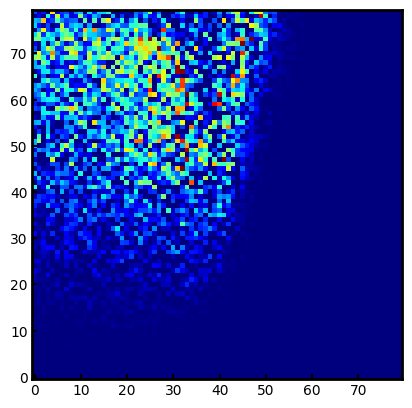

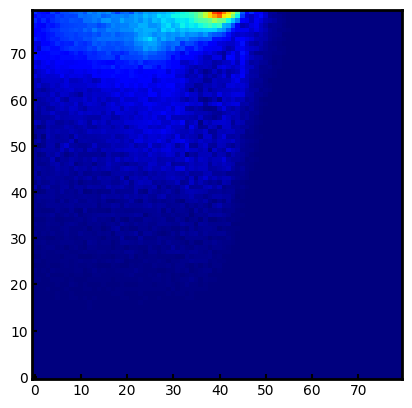

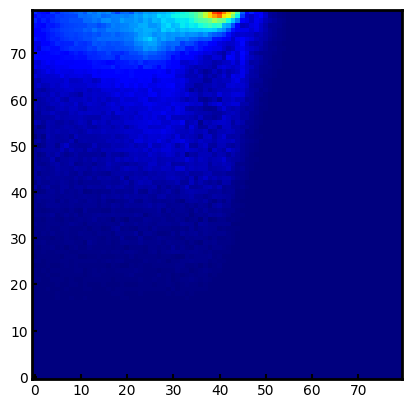

In [44]:
for i in range(len(xs)):
    plt.imshow(train_dataloader.dataset.unscale_data(xs[i].cpu().numpy(), input_type = 'hr')[0,0].T, vmin= 293, vmax = 5000,origin = 'lower', cmap = 'jet')
    frame_tick()
    plt.show()

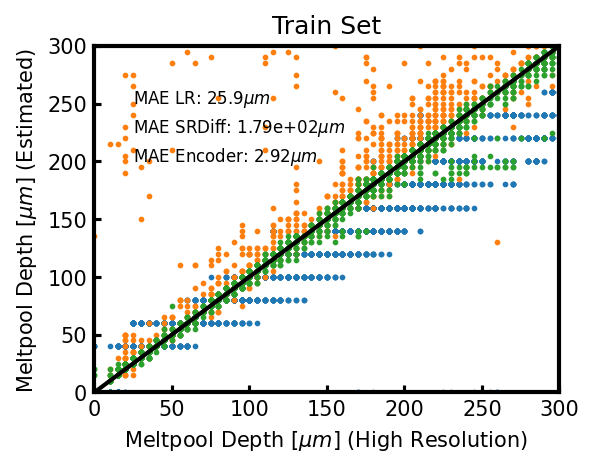

In [31]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(max_depth_gt, max_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')


mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth_diff)
mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)


plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Meltpool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Meltpool Depth [$\mu m]$ (Estimated) ')
plt.title('Train Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.text(25, 200,r'MAE Encoder: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )

# plt.savefig(os.path.join(analysis_folder, 'melt_pool_depth_validation_gridsearch.png'))
plt.show()

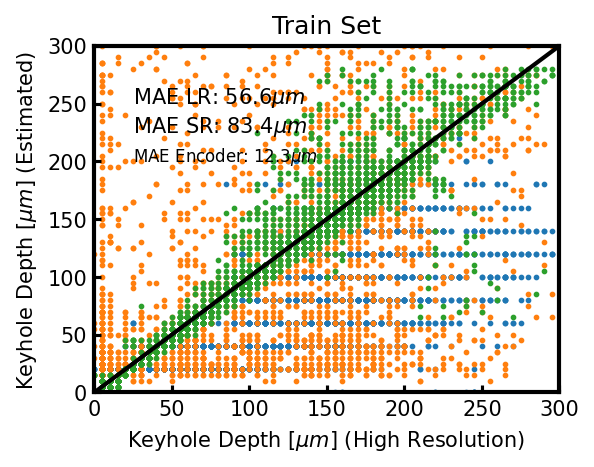

In [35]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth = mean_absolute_error(kp_depth_gt, kp_depth_diff)
mae_depth_enc = mean_absolute_error(kp_depth_gt, kp_depth_enc)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Train Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input) )
plt.text(25, 225,r'MAE SR: {:.03}$\mu m$'.format(mae_depth) )
plt.text(25, 200,r'MAE Encoder: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )

plt.savefig(os.path.join(analysis_folder, 'keyhole_depth_test_gridsearch.png'))

plt.show()